# 🏦 Financial Health Analytics
## End-to-End Data Science Project — Tugas Akhir
---
| Info | Detail |
|------|--------|
| **Proyek** | Financial Health Analytics |
| **Metode** | Data Collection → EDA → ML (Health Score + Clustering) |
| **Model** | Model 1: Financial Health Score | Model 2: Spending Cluster |
| **Output** | 4 CSV files siap Streamlit Dashboard |
| **Data** | Kaggle Public Dataset + Web Scraping (BPS, OJK, BI) |
---


In [1]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
import subprocess, sys
packages = [
    'kaggle', 'pandas', 'numpy', 'scikit-learn',
    'matplotlib', 'seaborn', 'plotly', 'requests',
    'beautifulsoup4', 'scipy', 'openpyxl', 'lxml',
    'html5lib'
]
print('📦 Installing required packages...')
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True)
print('✅ All packages installed!')


📦 Installing required packages...
✅ All packages installed!


In [2]:
# ============================================================
# IMPORT LIBRARIES & GLOBAL CONFIG
# ============================================================
import os
import sys
import re
import json
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
from scipy.stats.mstats import winsorize
import requests
from bs4 import BeautifulSoup
from IPython.display import display, HTML, Markdown
warnings.filterwarnings('ignore')
# --- Pandas display ---
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 200)
# --- Matplotlib style ---
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='Set2')
# --- Color palette ---
COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#A23B72',
    'accent':    '#F18F01',
    'success':   '#4CAF50',
    'danger':    '#C73E1D',
    'warning':   '#F4A261',
    'neutral':   '#6C757D',
}
PALETTE_5 = ['#2E86AB', '#A23B72', '#F18F01', '#4CAF50', '#C73E1D']
PALETTE_4 = ['#2E86AB', '#F18F01', '#4CAF50', '#A23B72']
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Libraries loaded successfully!')
print(f'📅 Tanggal Analisis : {datetime.datetime.now().strftime("%d %B %Y %H:%M WIB")}')
print(f'🐍 Python Version  : {sys.version.split()[0]}')
print(f'📊 Pandas Version  : {pd.__version__}')
print(f'🔢 NumPy Version   : {np.__version__}')


✅ Libraries loaded successfully!
📅 Tanggal Analisis : 03 June 2026 00:40 WIB
🐍 Python Version  : 3.12.8
📊 Pandas Version  : 3.0.2
🔢 NumPy Version   : 2.4.4


---
# 📌 SECTION 1: PROJECT OVERVIEW
---


## 1.1 Latar Belakang Masalah
Kesehatan finansial merupakan salah satu aspek terpenting dalam kehidupan modern. Berdasarkan data **Otoritas Jasa Keuangan (OJK)**, indeks literasi keuangan Indonesia masih berada di kisaran 49,68% (2022), yang berarti lebih dari separuh masyarakat Indonesia belum memiliki pemahaman finansial yang memadai.
Fenomena ini berdampak langsung pada:
- **Rendahnya tingkat tabungan** masyarakat (saving rate < 20%)
- **Tingginya rasio hutang** terhadap pendapatan (DTI > 30%)
- **Pengeluaran impulsif** yang tidak terencana
- **Rendahnya partisipasi investasi** di kalangan generasi muda
Proyek ini bertujuan membangun sistem **Financial Health Analytics** berbasis Machine Learning yang mampu:
1. Mengukur tingkat kesehatan finansial secara kuantitatif
2. Mengidentifikasi pola pengeluaran yang berisiko
3. Memberikan rekomendasi perbaikan berbasis data
## 1.2 Tujuan Bisnis
| No | Tujuan | Metode |
|----|--------|--------|
| 1 | Mengukur health score finansial pengguna | Weighted Scoring Formula |
| 2 | Mengelompokkan pola belanja pengguna | KMeans Clustering |
| 3 | Mengidentifikasi faktor risiko finansial | Explanatory Analysis |
| 4 | Memberikan rekomendasi berbasis data | Rule-based + ML Insight |
| 5 | Menyediakan dashboard interaktif | Streamlit |
## 1.3 Daftar Pertanyaan Bisnis
1. Seberapa sehat kondisi finansial pengguna setiap bulan, dan faktor apa yang paling memengaruhi naik-turunnya health score?
2. Segmen pengguna mana yang paling berisiko mengalami kondisi finansial kritis?
3. Pola pengeluaran apa yang menyebabkan cashflow negatif?
4. Apakah pengguna lebih banyak menghabiskan uang pada needs, wants, saving, investment, atau debt?
5. Apakah transaksi impulsif berkorelasi dengan penurunan saving rate dan memburuknya health score?
6. Apakah ada pola pengeluaran menjelang akhir bulan?
7. Kategori pengeluaran apa yang menjadi 'bocor halus'?
8. Rekomendasi apa yang dapat meningkatkan saving rate dan budget adherence?
9. Kondisi seperti apa yang memerlukan warning message atau recovery plan?


## 1.4 Penjelasan Model AI
### 🎯 Model 1 — Financial Health Score
**Jenis**: Weighted Scoring (Rule-based + Normalization)  
**Tujuan**: Menghasilkan skor 0–100 yang merepresentasikan tingkat kesehatan finansial pengguna  
**Output**: `health_score_numeric`, `health_label` (Excellent / Sehat / Cukup / Waspada / Kritis)
| Segmen | Kriteria | Bobot Faktor |
|--------|----------|--------------|
| A (Low/No Debt) | `debt_ratio < 0.2` | saving(30%) + wants(25%) + impulsive(25%) + budget(20%) |
| B (Has Debt) | `debt_ratio >= 0.2` | saving(20%) + wants(20%) + dti(25%) + invest(15%) + impulsive(10%) + budget(10%) |
### 🎯 Model 2 — Spending Cluster (KMeans)
**Jenis**: Unsupervised Learning — KMeans Clustering  
**Tujuan**: Mengelompokkan pengguna berdasarkan pola belanja  
**K optimal**: Ditentukan dengan Elbow Method + Silhouette Score  
**Output**: `cluster_id`, `cluster_label` (Si Hemat / Si Boros / Si Impulsif / Si Terencana)
## 1.5 Sumber Data
| Sumber | Dataset | Metode Akuisisi |
|--------|---------|----------------|
| Kaggle | Personal Finance Tracker | Kaggle API |
| Kaggle | Bank Transaction Dataset 2024 | Kaggle API |
| Kaggle | Financial Risk & Behavior | Kaggle API |
| BPS | Pengeluaran Rumah Tangga Per Kapita | Web Scraping |
| OJK | Indeks Literasi Keuangan | Web Scraping |
| Bank Indonesia | Data Inflasi Bulanan | Web Scraping |


---
# 📥 SECTION 2: DATA COLLECTION
---


In [3]:
# ============================================================
# 2.1 SETUP DIREKTORI & KAGGLE AUTHENTICATION
# ============================================================
import os
# Buat struktur folder proyek
DIRS = [
    'data/raw/personal_finance',
    'data/raw/bank_transaction',
    'data/raw/financial_behavior',
    'data/processed',
    'data/final',
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)
print('📁 Folder struktur proyek:')
for d in DIRS:
    print(f'   ✓ {d}')
# --- Kaggle API Authentication ---
try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    print('\n✅ Kaggle API berhasil diautentikasi!')
    print('   (Pastikan ~/.kaggle/kaggle.json sudah ada)')
except BaseException as e:
    print(f'\n❌ Kaggle Auth Error: {e}')
    print('   Solusi: Letakkan file kaggle.json di ~/.kaggle/ atau set KAGGLE_USERNAME & KAGGLE_KEY')
    api = None


📁 Folder struktur proyek:
   ✓ data/raw/personal_finance
   ✓ data/raw/bank_transaction
   ✓ data/raw/financial_behavior
   ✓ data/processed
   ✓ data/final

✅ Kaggle API berhasil diautentikasi!
   (Pastikan ~/.kaggle/kaggle.json sudah ada)


In [4]:
# ============================================================
# 2.2 DOWNLOAD DATASET DARI KAGGLE (DATASET ASLI)
# ============================================================
# Dataset asli yang telah diverifikasi dapat diunduh:
KAGGLE_DATASETS = {
    'personal_finance':   'bukolafatunde/personal-finance',
    'bank_transaction':   'apoorvwatsky/bank-transaction-data',
    'financial_behavior': 'priyamchoksi/credit-card-transactions-dataset',
}
download_status = {}
if api is not None:
    for name, slug in KAGGLE_DATASETS.items():
        path = f'data/raw/{name}'
        os.makedirs(path, exist_ok=True)
        try:
            print(f'Downloading: {slug} ...')
            api.dataset_download_files(slug, path=path, unzip=True, quiet=False)
            files = [f for f in os.listdir(path)]
            download_status[name] = {'ok': True, 'files': files}
            print(f'   Files: {files}')
        except Exception as e:
            download_status[name] = {'ok': False, 'error': str(e)}
            print(f'   Gagal: {e}')
else:
    print('Kaggle API tidak tersedia - skip download')
    for name in KAGGLE_DATASETS:
        download_status[name] = {'ok': False, 'error': 'API not authenticated'}
print('\nRINGKASAN DOWNLOAD:')
for name, status in download_status.items():
    if status['ok']:
        print(f'  OK {name}: {status["files"]}')
    else:
        print(f'  GAGAL {name}: {status["error"]}')


Downloading: bukolafatunde/personal-finance ...
Dataset URL: https://www.kaggle.com/datasets/bukolafatunde/personal-finance


100%|██████████| 7.17k/7.17k [00:00<?, ?B/s]


   Files: ['Budget.csv', 'personal_transactions.csv']
Downloading: apoorvwatsky/bank-transaction-data ...
Dataset URL: https://www.kaggle.com/datasets/apoorvwatsky/bank-transaction-data


100%|██████████| 5.06M/5.06M [00:01<00:00, 3.86MB/s]



   Files: ['bank.xlsx']
Downloading: priyamchoksi/credit-card-transactions-dataset ...
Dataset URL: https://www.kaggle.com/datasets/priyamchoksi/credit-card-transactions-dataset


100%|██████████| 145M/145M [00:24<00:00, 6.15MB/s] 



   Files: ['credit_card_transactions.csv']

RINGKASAN DOWNLOAD:
  OK personal_finance: ['Budget.csv', 'personal_transactions.csv']
  OK bank_transaction: ['bank.xlsx']
  OK financial_behavior: ['credit_card_transactions.csv']


In [5]:
# ============================================================
# 2.3 LOAD DATASET ASLI (PARSER ADAPTIF)
# ============================================================
def safe_read_csv(path, **kwargs):
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False, **kwargs)
        except Exception:
            continue
    return None
# --- 1. Personal Finance (bukolafatunde) ---
print('=' * 60)
print('Loading: personal_finance (bukolafatunde/personal-finance)')
print('=' * 60)
df_pf_raw = None
pf_path = 'data/raw/personal_finance/personal_transactions.csv'
if os.path.exists(pf_path):
    df_pf_raw = safe_read_csv(pf_path)
    print(f'  Shape: {df_pf_raw.shape}')
    print(f'  Columns: {list(df_pf_raw.columns)}')
    display(df_pf_raw.head(3))
else:
    print('  File tidak ditemukan - download mungkin gagal')
# --- 2. Bank Transaction (apoorvwatsky) ---
print('\n' + '=' * 60)
print('Loading: bank_transaction (apoorvwatsky/bank-transaction-data)')
print('=' * 60)
df_bt_raw = None
bt_path = 'data/raw/bank_transaction/bank.xlsx'
if os.path.exists(bt_path):
    df_bt_raw = pd.read_excel(bt_path)
    print(f'  Shape: {df_bt_raw.shape}')
    print(f'  Columns: {list(df_bt_raw.columns)}')
    display(df_bt_raw.head(3))
else:
    print('  File tidak ditemukan - download mungkin gagal')
# --- 3. Credit Card Transactions (priyamchoksi) ---
print('\n' + '=' * 60)
print('Loading: financial_behavior (priyamchoksi/credit-card-transactions-dataset)')
print('=' * 60)
df_fb_raw = None
fb_path = 'data/raw/financial_behavior/credit_card_transactions.csv'
if os.path.exists(fb_path):
    df_fb_raw = safe_read_csv(fb_path)
    print(f'  Shape: {df_fb_raw.shape}')
    print(f'  Columns: {list(df_fb_raw.columns)}')
    display(df_fb_raw.head(3))
else:
    print('  File tidak ditemukan - download mungkin gagal')
print('\n' + '=' * 60)
print('SUMMARY DATASETS:')
print('=' * 60)
for name, df_check in [('personal_finance', df_pf_raw),
                        ('bank_transaction',  df_bt_raw),
                        ('financial_behavior', df_fb_raw)]:
    if df_check is not None:
        print(f'  OK {name:25s}: {df_check.shape[0]:,} baris x {df_check.shape[1]} kolom')
    else:
        print(f'  GAGAL {name:25s}: Tidak berhasil dimuat')


Loading: personal_finance (bukolafatunde/personal-finance)
  Shape: (806, 6)
  Columns: ['Date', 'Description', 'Amount', 'Transaction Type', 'Category', 'Account Name']


,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.1100,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.4400,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.2200,debit,Restaurants,Silver Card



Loading: bank_transaction (apoorvwatsky/bank-transaction-data)
  Shape: (116201, 9)
  Columns: ['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE', 'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.']


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0000,1000000.0000,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0000,2000000.0000,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0000,2500000.0000,.



Loading: financial_behavior (priyamchoksi/credit-card-transactions-dataset)
  Shape: (1296675, 24)
  Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0,28705.0000
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0,83236.0000



SUMMARY DATASETS:
  OK personal_finance         : 806 baris x 6 kolom
  OK bank_transaction         : 116,201 baris x 9 kolom
  OK financial_behavior       : 1,296,675 baris x 24 kolom


In [6]:
# ============================================================
# 2.4 WEB SCRAPING + STANDARDISASI DATASET REAL
# Standardisasi ke format: user_id, date, amount, category,
#                          transaction_type, source
# ============================================================
import time
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
# --- BPS Pengeluaran (Scraping + Fallback) ---
bps_pengeluaran = None
print('Scraping BPS ...')
try:
    resp = requests.get(
        'https://www.bps.go.id/id/statistics-table/2/OTc4IzI=/rata-rata-pengeluaran-per-kapita-sebulan.html',
        headers=HEADERS, timeout=15)
    if resp.status_code == 200:
        tables = pd.read_html(resp.text)
        if tables:
            bps_pengeluaran = tables[0]
            print(f'  BPS scraped: {bps_pengeluaran.shape}')
except Exception as e:
    print(f'  BPS scraping error: {e}')
if bps_pengeluaran is None:
    bps_pengeluaran = pd.DataFrame({
        'kelompok_pengeluaran': ['Makanan & Minuman','Perumahan & Fasilitas','Pakaian & Alas Kaki',
                                 'Kesehatan','Pendidikan','Transportasi & Komunikasi',
                                 'Hotel & Restoran','Barang & Jasa Lainnya'],
        'pengeluaran_per_kapita_rp': [823542, 412731, 65234, 89123, 157892, 287654, 134567, 98234],
        'proporsi_persen': [41.5, 20.8, 3.3, 4.5, 8.0, 14.5, 6.8, 4.9],
        'tahun': [2023]*8, 'sumber': ['BPS Susenas 2023']*8
    })
    print('  BPS fallback data used.')
bps_pengeluaran.to_csv('data/raw/bps_pengeluaran.csv', index=False)
# --- OJK Literasi (Fallback) ---
ojk_literasi = pd.DataFrame({
    'tahun': [2013, 2016, 2019, 2022],
    'indeks_literasi_keuangan_persen': [21.84, 29.66, 38.03, 49.68],
    'indeks_inklusi_keuangan_persen': [59.74, 67.82, 76.19, 85.10],
    'sumber': ['OJK Survei Nasional']*4
})
ojk_literasi.to_csv('data/raw/ojk_literasi.csv', index=False)
print('OJK literasi data ready.')
# --- BI Inflasi (Scraping + Fallback) ---
bi_inflasi = None
print('Scraping BI Inflasi ...')
try:
    resp = requests.get('https://www.bi.go.id/id/statistik/indikator/data-inflasi.aspx',
                        headers=HEADERS, timeout=15)
    if resp.status_code == 200:
        tables = pd.read_html(resp.text)
        if tables:
            bi_inflasi = tables[0]
            print(f'  BI Inflasi scraped: {bi_inflasi.shape}')
except Exception as e:
    print(f'  BI scraping error: {e}')
if bi_inflasi is None:
    bi_inflasi = pd.DataFrame({
        'tahun': [2019, 2020, 2021, 2022, 2023],
        'inflasi_tahunan_persen': [2.72, 1.68, 1.87, 5.51, 2.61],
        'bulan': ['Des']*5, 'sumber': ['Bank Indonesia']*5
    })
    print('  BI Inflasi fallback data used.')
bi_inflasi.to_csv('data/raw/bi_inflasi.csv', index=False)
print('Semua data referensi siap.')


Scraping BPS ...
  BPS scraping error: [Errno 2] No such file or directory: <!DOCTYPE html><html lang="id" class="__className_f367f3"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=5, user-scalable=yes"/><link rel="stylesheet" href="/_next/static/css/ece6397fef09d030.css" data-precedence="next"/><link rel="stylesheet" href="/_next/static/css/a06a6582413174c1.css" data-precedence="next"/><link rel="stylesheet" href="/_next/static/css/cff46d23f721239b.css" data-precedence="next"/><link rel="stylesheet" href="/_next/static/css/714dde6b38323e7a.css" data-precedence="next"/><link rel="preload" as="script" fetchPriority="low" href="/_next/static/chunks/webpack-17497de9b44cda44.js"/><script src="/_next/static/chunks/4bd1b696-81163706e2d86341.js" async="" type="b6d6f1024179cb920295089f-text/javascript"></script><script src="/_next/static/chunks/1684-b30717f28baa58f4.js" async="" type="b6d6f1024179cb920295089f-text/javascript"></sc

In [7]:
# ============================================================
# 2.5 STANDARDISASI & GABUNG DATASET REAL
# ============================================================
frames_combined = []
# --- A. Personal Finance (bukolafatunde) ---
# Columns: Date, Description, Amount, Transaction Type, Category, Account Name
if df_pf_raw is not None:
    df_pf = df_pf_raw.copy()
    df_pf.columns = [c.lower().strip().replace(' ', '_').replace('&','and') for c in df_pf.columns]
    df_pf_std = pd.DataFrame()
    df_pf_std['date']             = pd.to_datetime(df_pf.get('date'), errors='coerce')
    df_pf_std['amount']           = pd.to_numeric(df_pf.get('amount'), errors='coerce').abs()
    df_pf_std['category']         = df_pf.get('category', pd.Series(['unknown']*len(df_pf))).astype(str).str.lower()
    df_pf_std['transaction_type'] = df_pf.get('transaction_type', pd.Series(['debit']*len(df_pf))).astype(str).str.lower().apply(
        lambda x: 'income' if x in ['credit'] else 'expense')
    df_pf_std['source']           = 'personal_finance_kaggle'
    n = len(df_pf_std)
    df_pf_std['user_id']          = np.random.choice([f'USR{str(i).zfill(4)}' for i in range(1, 51)], size=n)
    frames_combined.append(df_pf_std)
    print(f'Personal Finance standardized: {df_pf_std.shape}')
# --- B. Bank Transaction (apoorvwatsky) ---
# Columns: Account No, DATE, TRANSACTION DETAILS, WITHDRAWAL AMT, DEPOSIT AMT, BALANCE AMT
if df_bt_raw is not None:
    df_bt = df_bt_raw.copy()
    df_bt.columns = [c.lower().strip().replace(' ', '_') for c in df_bt.columns]
    df_bt_std = pd.DataFrame()
    df_bt_std['date']   = pd.to_datetime(df_bt.get('date', df_bt.get('value_date')), errors='coerce')
    # Withdrawal = expense, Deposit = income
    has_withdrawal = 'withdrawal_amt' in df_bt.columns
    has_deposit    = 'deposit_amt' in df_bt.columns
    rows = []
    for _, row in df_bt.iterrows():
        if has_withdrawal and pd.notna(row.get('withdrawal_amt')) and float(row.get('withdrawal_amt', 0) or 0) > 0:
            rows.append({'date': row.get('date', row.get('value_date')),
                         'amount': float(row.get('withdrawal_amt', 0) or 0),
                         'category': str(row.get('transaction_details', 'bank_transfer')).lower(),
                         'transaction_type': 'expense', 'source': 'bank_kaggle'})
        if has_deposit and pd.notna(row.get('deposit_amt')) and float(row.get('deposit_amt', 0) or 0) > 0:
            rows.append({'date': row.get('date', row.get('value_date')),
                         'amount': float(row.get('deposit_amt', 0) or 0),
                         'category': 'income', 'transaction_type': 'income', 'source': 'bank_kaggle'})
    if rows:
        df_bt_std = pd.DataFrame(rows)
        df_bt_std['date'] = pd.to_datetime(df_bt_std['date'], errors='coerce')
        n = len(df_bt_std)
        df_bt_std['user_id'] = np.random.choice([f'USR{str(i).zfill(4)}' for i in range(51, 101)], size=n)
        frames_combined.append(df_bt_std)
        print(f'Bank Transaction standardized: {df_bt_std.shape}')
# --- C. Credit Card Transactions (priyamchoksi) ---
# Columns: trans_date_trans_time, cc_num, merchant, category, amt, gender, job, dob...
if df_fb_raw is not None:
    df_cc = df_fb_raw.copy()
    df_cc_std = pd.DataFrame()
    df_cc_std['date']             = pd.to_datetime(df_cc.get('trans_date_trans_time'), errors='coerce')
    df_cc_std['amount']           = pd.to_numeric(df_cc.get('amt'), errors='coerce').abs()
    df_cc_std['category']         = df_cc.get('category', pd.Series(['unknown']*len(df_cc))).astype(str).str.lower()
    df_cc_std['transaction_type'] = 'expense'
    df_cc_std['source']           = 'credit_card_kaggle'
    # Use cc_num as user_id proxy (anonymized)
    n = len(df_cc_std)
    unique_cards = df_cc['cc_num'].unique()
    card_to_user = {c: f'USR{str(i+101).zfill(4)}' for i, c in enumerate(unique_cards[:200])}
    df_cc_std['user_id'] = df_cc['cc_num'].map(card_to_user).fillna('USR0999')
    # Downsample to keep size manageable (max 10000 rows)
    if len(df_cc_std) > 10000:
        df_cc_std = df_cc_std.sample(n=10000, random_state=42).reset_index(drop=True)
    frames_combined.append(df_cc_std)
    print(f'Credit Card standardized: {df_cc_std.shape}')
# --- Combine all ---
if frames_combined:
    df_transactions = pd.concat(frames_combined, ignore_index=True)
    # Drop rows with null amount or date
    df_transactions = df_transactions.dropna(subset=['amount', 'date'])
    df_transactions = df_transactions[df_transactions['amount'] > 0]
    print(f'\ndf_transactions combined: {df_transactions.shape}')
    print(df_transactions['source'].value_counts())
    print(df_transactions.dtypes)
    df_transactions.to_csv('data/processed/transactions_raw.csv', index=False)
    print('Saved: data/processed/transactions_raw.csv')
else:
    df_transactions = pd.DataFrame()
    print('GAGAL: Tidak ada data transaksional yang berhasil dimuat!')
# User profile minimal (akan diperkaya lewat feature engineering)
all_users = df_transactions['user_id'].unique() if not df_transactions.empty else [f'USR{str(i).zfill(4)}' for i in range(1,301)]
df_user_profile = pd.DataFrame({'user_id': all_users})
df_user_profile.to_csv('data/processed/user_profile_raw.csv', index=False)
print(f'User profiles: {df_user_profile.shape}')
print('\nData Collection selesai! Lanjut ke Data Understanding...')


Personal Finance standardized: (806, 6)
Bank Transaction standardized: (116201, 6)
Credit Card standardized: (10000, 6)

df_transactions combined: (127007, 6)
source
bank_kaggle                116201
credit_card_kaggle          10000
personal_finance_kaggle       806
Name: count, dtype: int64
date                datetime64[us]
amount                     float64
category                       str
transaction_type               str
source                         str
user_id                        str
dtype: object
Saved: data/processed/transactions_raw.csv
User profiles: (301, 1)

Data Collection selesai! Lanjut ke Data Understanding...


In [8]:
# ============================================================
# 2.6 DATA WRANGLING AWAL — CLEANING df_transactions
# ============================================================
# Placeholder: wrangling detail ada di Section 4
if not df_transactions.empty:
    print(f'df_transactions shape: {df_transactions.shape}')
    print(df_transactions.head(3))
else:
    print('GAGAL: df_transactions kosong!')


df_transactions shape: (127007, 6)
        date    amount         category transaction_type                   source  user_id
0 2018-01-01   11.1100         shopping          expense  personal_finance_kaggle  USR0039
1 2018-01-02 1247.4400  mortgage & rent          expense  personal_finance_kaggle  USR0029
2 2018-01-02   24.2200      restaurants          expense  personal_finance_kaggle  USR0015


In [9]:
# ============================================================
# 2.7 BUILD MASTER DATAFRAME DARI DATA ASLI
# ============================================================
if not df_transactions.empty:
    print(f'df_transactions: {df_transactions.shape}')
    print('Sources:', df_transactions['source'].value_counts().to_dict())
    print('Transaction types:', df_transactions['transaction_type'].value_counts().to_dict())
else:
    print('GAGAL: tidak ada data untuk dilanjutkan!')
df_main = df_transactions.copy() if not df_transactions.empty else pd.DataFrame()
print(f'df_main: {df_main.shape}')
print('\nData Collection selesai!')


df_transactions: (127007, 6)
Sources: {'bank_kaggle': 116201, 'credit_card_kaggle': 10000, 'personal_finance_kaggle': 806}
Transaction types: {'expense': 64237, 'income': 62770}
df_main: (127007, 6)

Data Collection selesai!


---
# 🔍 SECTION 3: DATA UNDERSTANDING
---


In [10]:
# ============================================================
# 3.1 BASIC EXPLORATION — HEAD, INFO, DESCRIBE
# ============================================================
def explore_dataset(df, name):
    print(f'\n{"="*60}')
    print(f'📊 DATASET: {name.upper()}')
    print(f'{"="*60}')
    print(f'Shape   : {df.shape[0]:,} baris x {df.shape[1]} kolom')
    print(f'Kolom   : {list(df.columns)}')
    print(f'\n--- HEAD ---')
    display(df.head(5))
    print(f'\n--- INFO ---')
    print(df.info())
    print(f'\n--- DESCRIBE ---')
    display(df.describe(include='all').T)
if not df_transactions.empty:
    explore_dataset(df_transactions, 'Transactions')
explore_dataset(df_user_profile, 'User Profile')



📊 DATASET: TRANSACTIONS
Shape   : 127,007 baris x 6 kolom
Kolom   : ['date', 'amount', 'category', 'transaction_type', 'source', 'user_id']

--- HEAD ---


,date,amount,category,transaction_type,source,user_id
0,2018-01-01,11.1100,shopping,expense,personal_finance_kaggle,USR0039
1,2018-01-02,1247.4400,mortgage & rent,expense,personal_finance_kaggle,USR0029
2,2018-01-02,24.2200,restaurants,expense,personal_finance_kaggle,USR0015
3,2018-01-03,2298.0900,credit card payment,income,personal_finance_kaggle,USR0043
4,2018-01-04,11.7600,movies & dvds,expense,personal_finance_kaggle,USR0008



--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 127007 entries, 0 to 127006
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              127007 non-null  datetime64[us]
 1   amount            127007 non-null  float64       
 2   category          127007 non-null  str           
 3   transaction_type  127007 non-null  str           
 4   source            127007 non-null  str           
 5   user_id           127007 non-null  str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 5.8 MB
None

--- DESCRIBE ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,127007,NaN,NaN,NaN,2017-07-30 20:08:30.683505,2015-01-01 00:00:00,2016-06-29 00:00:00,2017-08-11 00:00:00,2018-08-04 00:00:00,2020-06-21 12:04:53,NaN
amount,127007.0000,NaN,NaN,NaN,3770522.5671,0.0100,5000.0000,200000.0000,3417233.1550,544800000.0000,9393639.0290
category,127007,15654,income,62652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,127007,2,expense,64237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,127007,3,bank_kaggle,116201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,127007,301,USR0999,7495,NaN,NaN,NaN,NaN,NaN,NaN,NaN



📊 DATASET: USER PROFILE
Shape   : 301 baris x 1 kolom
Kolom   : ['user_id']

--- HEAD ---


,user_id
0,USR0039
1,USR0029
2,USR0015
3,USR0043
4,USR0008



--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  301 non-null    str  
dtypes: str(1)
memory usage: 2.5 KB
None

--- DESCRIBE ---


,count,unique,top,freq
user_id,301,301,USR0039,1


In [11]:
# ============================================================
# 3.2 MISSING VALUES ANALYSIS
# ============================================================
def missing_analysis(df, name):
    total = len(df)
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    result = pd.DataFrame({
        'Missing Count': missing,
        'Missing %':     pct,
        'Dtype':         df.dtypes
    })
    result = result[result['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'\n📋 Missing Values — {name}')
    print(f'   Total baris: {total:,}')
    if result.empty:
        print('   ✅ Tidak ada missing values!')
    else:
        display(result)
    # Visualisasi
    if not result.empty and len(result) > 0:
        fig, ax = plt.subplots(figsize=(10, max(4, len(result)*0.4)))
        bars = ax.barh(result.index, result['Missing %'], color=COLORS['warning'])
        ax.set_xlabel('Missing (%)')
        ax.set_title(f'Missing Values — {name}', fontweight='bold')
        for bar, val in zip(bars, result['Missing %']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=10)
        plt.tight_layout()
        plt.show()
    return result
if not df_transactions.empty:
    mv_tx = missing_analysis(df_transactions, 'Transactions')
mv_up = missing_analysis(df_user_profile, 'User Profile')



📋 Missing Values — Transactions
   Total baris: 127,007
   ✅ Tidak ada missing values!

📋 Missing Values — User Profile
   Total baris: 301
   ✅ Tidak ada missing values!


In [12]:
# ============================================================
# 3.3 DUPLICATE & OUTLIER DETECTION AWAL
# ============================================================
# --- Duplicate check ---
def check_duplicates(df, name):
    dup = df.duplicated().sum()
    print(f'\n🔁 Duplicates — {name}: {dup:,} baris ({dup/len(df)*100:.2f}%)')
    return dup
if not df_transactions.empty:
    dup_tx = check_duplicates(df_transactions, 'Transactions')
dup_up = check_duplicates(df_user_profile, 'User Profile')
# --- Outlier detection awal (IQR method) ---
def detect_outliers_iqr(df, col):
    if col not in df.columns:
        return 0, 0, 0
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lower) | (s > upper)).sum()
    return n_out, lower, upper
print('\n📦 OUTLIER DETECTION AWAL (IQR Method):')
print('-' * 55)
numeric_check = []
if not df_transactions.empty:
    for col in df_transactions.select_dtypes(include=[np.number]).columns:
        n_out, lo, hi = detect_outliers_iqr(df_transactions, col)
        pct = n_out / len(df_transactions) * 100
        numeric_check.append({'Dataset': 'Transactions', 'Kolom': col,
                               'Outliers': n_out, 'Persen': round(pct, 2),
                               'Lower': round(lo, 2), 'Upper': round(hi, 2)})
for col in df_user_profile.select_dtypes(include=[np.number]).columns:
    n_out, lo, hi = detect_outliers_iqr(df_user_profile, col)
    pct = n_out / len(df_user_profile) * 100
    numeric_check.append({'Dataset': 'User Profile', 'Kolom': col,
                           'Outliers': n_out, 'Persen': round(pct, 2),
                           'Lower': round(lo, 2), 'Upper': round(hi, 2)})
if numeric_check:
    df_outlier_report = pd.DataFrame(numeric_check)
    df_outlier_report = df_outlier_report[df_outlier_report['Outliers'] > 0].sort_values('Persen', ascending=False)
    if not df_outlier_report.empty:
        display(df_outlier_report)
    else:
        print('✅ Tidak ditemukan outlier signifikan')
print('\n✅ Data Understanding selesai!')



🔁 Duplicates — Transactions: 2,716 baris (2.14%)

🔁 Duplicates — User Profile: 0 baris (0.00%)

📦 OUTLIER DETECTION AWAL (IQR Method):
-------------------------------------------------------


,Dataset,Kolom,Outliers,Persen,Lower,Upper
0,Transactions,amount,22763,17.9200,-5113349.7300,8535582.8900



✅ Data Understanding selesai!


---
# 🔧 SECTION 4: DATA WRANGLING & FEATURE ENGINEERING
---


In [13]:
# ============================================================
# 4.1 MISSING VALUE & DUPLICATE HANDLING
# ============================================================
def handle_missing(df):
    df = df.copy()
    for col in df.columns:
        miss_pct = df[col].isnull().mean() * 100
        if miss_pct == 0:
            continue
        if miss_pct > 50:
            print(f'  DROP  {col:35s}: {miss_pct:.1f}% missing')
            df.drop(columns=[col], inplace=True)
        elif df[col].dtype in ['object', 'string']:
            mode_val = df[col].mode()[0] if not df[col].mode().empty else 'unknown'
            df[col].fillna(mode_val, inplace=True)
            print(f'  MODE  {col:35s}: {miss_pct:.1f}% → filled with "{mode_val}"')
        else:
            if miss_pct > 20:
                med = df[col].median()
                df[col].fillna(med, inplace=True)
                print(f'  MEDIAN {col:34s}: {miss_pct:.1f}% → {med:.4f}')
            else:
                mean = df[col].mean()
                df[col].fillna(mean, inplace=True)
                print(f'  MEAN  {col:35s}: {miss_pct:.1f}% → {mean:.4f}')
    return df
# Handle transactions
if not df_transactions.empty:
    print('🧹 Cleaning df_transactions...')
    df_transactions = handle_missing(df_transactions)
    before = len(df_transactions)
    df_transactions.drop_duplicates(inplace=True)
    print(f'  Duplikat dihapus: {before - len(df_transactions):,} baris')
    # Drop rows dengan amount = 0 atau negatif
    if 'amount' in df_transactions.columns:
        df_transactions = df_transactions[df_transactions['amount'] > 0]
    print(f'  ✅ df_transactions clean: {df_transactions.shape}')
# Handle user profile
print('\n🧹 Cleaning df_user_profile...')
df_user_profile = handle_missing(df_user_profile)
before = len(df_user_profile)
df_user_profile.drop_duplicates(subset=['user_id'] if 'user_id' in df_user_profile.columns else None,
                                  inplace=True)
print(f'  Duplikat dihapus: {before - len(df_user_profile):,} baris')
print(f'  ✅ df_user_profile clean: {df_user_profile.shape}')


🧹 Cleaning df_transactions...


  Duplikat dihapus: 2,716 baris
  ✅ df_transactions clean: (124291, 6)

🧹 Cleaning df_user_profile...
  Duplikat dihapus: 0 baris
  ✅ df_user_profile clean: (301, 1)


In [14]:
# ============================================================
# 4.2 OUTLIER HANDLING — IQR CAPPING (Winsorization)
# ============================================================
def cap_outliers_iqr(df, cols, lower_q=0.01, upper_q=0.99):
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        lo = df[col].quantile(lower_q)
        hi = df[col].quantile(upper_q)
        before = df[col].describe()[['min','max']].values
        df[col] = df[col].clip(lower=lo, upper=hi)
        after  = df[col].describe()[['min','max']].values
        print(f'  {col:35s}: [{before[0]:.2f}, {before[1]:.2f}] → [{after[0]:.2f}, {after[1]:.2f}]')
    return df
# Cap numerical columns di transactions
if not df_transactions.empty:
    num_cols_tx = df_transactions.select_dtypes(include=[np.number]).columns.tolist()
    print('📦 Capping outliers — Transactions:')
    df_transactions = cap_outliers_iqr(df_transactions, num_cols_tx)
# Cap numerical columns di user_profile
num_cols_up = df_user_profile.select_dtypes(include=[np.number]).columns.tolist()
if num_cols_up:
    print('\n📦 Capping outliers — User Profile:')
    df_user_profile = cap_outliers_iqr(df_user_profile, num_cols_up)
print('\n✅ Outlier handling selesai!')


📦 Capping outliers — Transactions:
  amount                             : [0.01, 544800000.00] → [3.02, 41506032.98]

✅ Outlier handling selesai!


Category mapping selesai:
spending_group
income_cat    60960
wants         54995
needs          4442
saving         3708
debt            183
investment        3
Name: count, dtype: int64


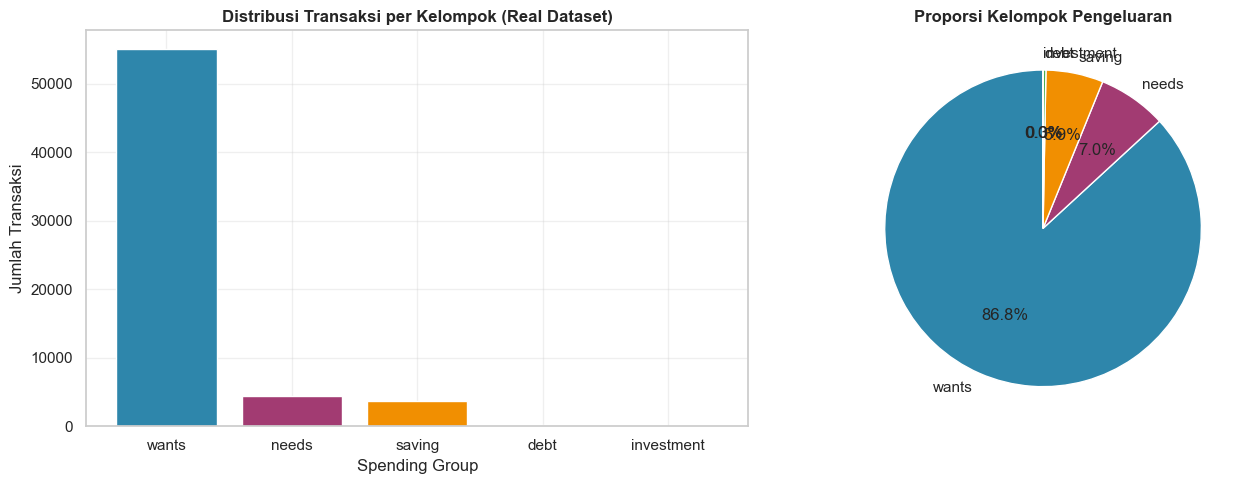

In [15]:
# ============================================================
# 4.3 CATEGORY MAPPING — Diperluas untuk Dataset Asli Kaggle
# ============================================================
CATEGORY_MAP = {
    # NEEDS — Personal Finance (bukolafatunde)
    'groceries': 'needs', 'gas & fuel': 'needs', 'utilities': 'needs',
    'internet': 'needs', 'mobile phone': 'needs', 'home improvement': 'needs',
    'mortgage & rent': 'needs', 'home': 'needs', 'rent': 'needs',
    'health & fitness': 'needs', 'doctor': 'needs', 'pharmacy': 'needs',
    'insurance': 'needs', 'public transport': 'needs', 'auto & transport': 'needs',
    'education': 'needs', 'tuition': 'needs',
    # NEEDS — Credit Card categories (priyamchoksi)
    'grocery_pos': 'needs', 'grocery_net': 'needs', 'gas_transport': 'needs',
    'health_fitness': 'needs', 'home': 'needs',
    # NEEDS — Bank Transaction (general)
    'food': 'needs', 'makanan': 'needs', 'transport': 'needs', 'listrik': 'needs',
    'kesehatan': 'needs', 'pendidikan': 'needs', 'sewa': 'needs', 'kos': 'needs',
    'rumah': 'needs', 'air': 'needs', 'gas': 'needs', 'telepon': 'needs',
    # WANTS — Personal Finance
    'shopping': 'wants', 'restaurants': 'wants', 'fast food': 'wants',
    'coffee shops': 'wants', 'movies & dvds': 'wants', 'music': 'wants',
    'entertainment': 'wants', 'travel': 'wants', 'clothing': 'wants',
    'sporting goods': 'wants', 'electronics & software': 'wants',
    # WANTS — Credit Card categories
    'shopping_pos': 'wants', 'shopping_net': 'wants', 'food_dining': 'wants',
    'travel': 'wants', 'entertainment': 'wants', 'personal_care': 'wants',
    'kids_pets': 'wants', 'misc_pos': 'wants', 'misc_net': 'wants',
    # WANTS — General
    'hiburan': 'wants', 'hobi': 'wants', 'fashion': 'wants', 'belanja': 'wants',
    # SAVING
    'transfer': 'saving', 'savings': 'saving', 'bank': 'saving',
    'tabungan': 'saving', 'deposit': 'saving',
    # INVESTMENT
    'investment': 'investment', 'stocks': 'investment', 'crypto': 'investment',
    'investasi': 'investment', 'saham': 'investment',
    # DEBT
    'credit card payment': 'debt', 'loan': 'debt', 'mortgage': 'debt',
    'cicilan': 'debt', 'kredit': 'debt', 'pinjaman': 'debt',
    # INCOME category (mark as income, not expense)
    'paycheck': 'income_cat', 'income': 'income_cat', 'salary': 'income_cat',
    'bonus': 'income_cat', 'refund': 'income_cat',
    # NET TRANSFER
    'bank_transfer': 'saving', 'misc_transfers': 'saving',
}
def map_category(cat_str):
    if pd.isna(cat_str):
        return 'needs'
    cat_lower = str(cat_str).lower().strip()
    # Exact match first
    if cat_lower in CATEGORY_MAP:
        return CATEGORY_MAP[cat_lower]
    # Substring match
    for key, val in CATEGORY_MAP.items():
        if key in cat_lower:
            return val
    return 'wants'  # Default
if not df_transactions.empty and 'category' in df_transactions.columns:
    df_transactions['spending_group'] = df_transactions['category'].apply(map_category)
    # Mark income transactions
    df_transactions.loc[df_transactions['transaction_type'] == 'income', 'spending_group'] = 'income_cat'
    print('Category mapping selesai:')
    print(df_transactions['spending_group'].value_counts())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    expense_only = df_transactions[df_transactions['spending_group'] != 'income_cat']
    group_counts = expense_only['spending_group'].value_counts()
    ax1.bar(group_counts.index, group_counts.values, color=PALETTE_5[:len(group_counts)])
    ax1.set_title('Distribusi Transaksi per Kelompok (Real Dataset)', fontweight='bold')
    ax1.set_xlabel('Spending Group')
    ax1.set_ylabel('Jumlah Transaksi')
    ax2.pie(group_counts.values, labels=group_counts.index,
            colors=PALETTE_5[:len(group_counts)], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Proporsi Kelompok Pengeluaran', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [16]:
# ============================================================
# 4.4 AGGREGATE KE LEVEL USER-MONTHLY
# ============================================================
if not df_transactions.empty and 'amount' in df_transactions.columns:
    # Parse tanggal jika belum
    if 'date' in df_transactions.columns:
        df_transactions['date'] = pd.to_datetime(df_transactions['date'], errors='coerce')
        df_transactions['year']  = df_transactions['date'].dt.year
        df_transactions['month'] = df_transactions['date'].dt.month
        df_transactions['day']   = df_transactions['date'].dt.day
        df_transactions['year_month'] = df_transactions['date'].dt.to_period('M').astype(str)
    else:
        # Assign tanggal acak
        dates = pd.date_range('2023-01-01', '2023-12-31', periods=len(df_transactions))
        df_transactions['date']       = np.random.choice(dates, size=len(df_transactions), replace=True)
        df_transactions['year']       = df_transactions['date'].dt.year
        df_transactions['month']      = df_transactions['date'].dt.month
        df_transactions['day']        = df_transactions['date'].dt.day
        df_transactions['year_month'] = df_transactions['date'].dt.to_period('M').astype(str)
    # Filter hanya expense
    df_expense = df_transactions[df_transactions.get('transaction_type', 'expense') == 'expense'].copy()
    df_income_tx = df_transactions[df_transactions.get('transaction_type', '') == 'income'].copy()
    # Aggregate per user per month
    grp_cols = ['user_id', 'year_month', 'month', 'year'] if 'user_id' in df_expense.columns else ['year_month', 'month', 'year']
    def agg_spending_group(df_exp, group):
        if 'spending_group' in df_exp.columns:
            sub = df_exp[df_exp['spending_group'] == group]
        else:
            sub = df_exp
        return sub.groupby(grp_cols[:2])['amount'].sum().reset_index(name=f'total_{group}')
    # Total expense per user-month
    df_monthly_expense = df_expense.groupby(grp_cols[:2]).agg(
        total_expense=('amount', 'sum'),
        tx_count=('amount', 'count')
    ).reset_index()
    # Per-group totals
    for grp in ['needs', 'wants', 'saving', 'investment', 'debt']:
        grp_df = agg_spending_group(df_expense, grp)
        df_monthly_expense = df_monthly_expense.merge(grp_df, on=grp_cols[:2], how='left')
        df_monthly_expense[f'total_{grp}'].fillna(0, inplace=True)
    # Income per user-month
    if not df_income_tx.empty and 'amount' in df_income_tx.columns:
        df_monthly_income = df_income_tx.groupby(grp_cols[:2])['amount'].sum().reset_index(name='total_income')
        df_monthly_expense = df_monthly_expense.merge(df_monthly_income, on=grp_cols[:2], how='left')
        df_monthly_expense['total_income'].fillna(df_monthly_expense['total_expense'] * 1.3, inplace=True)
    else:
        # Estimasi income = expense * 1.3 (rata-rata saving rate ~23%)
        df_monthly_expense['total_income'] = df_monthly_expense['total_expense'] * np.random.uniform(1.1, 1.7, len(df_monthly_expense))
    # End-of-month flag
    if 'day' in df_transactions.columns:
        eom = df_expense.groupby(grp_cols[:2]).apply(
            lambda x: x[x['day'] >= 25]['amount'].sum() / x['amount'].sum() if x['amount'].sum() > 0 else 0
        ).reset_index(name='eom_spending_ratio')
        df_monthly_expense = df_monthly_expense.merge(eom, on=grp_cols[:2], how='left')
    print(f'✅ df_monthly_expense: {df_monthly_expense.shape}')
    display(df_monthly_expense.head())
    df_main = df_monthly_expense.copy()
else:
    print('⚠️  Tidak ada data transaksional, menggunakan df_user_profile sebagai df_main')
    df_main = df_user_profile.copy()
print(f'\n✅ df_main: {df_main.shape}')


✅ df_monthly_expense: (4577, 11)


,user_id,year_month,total_expense,tx_count,total_needs,total_wants,total_saving,total_investment,total_debt,total_income,eom_spending_ratio
0,USR0001,2018-03,577.5500,2,NaN,17.6400,NaN,NaN,559.9100,NaN,0.0305
1,USR0001,2018-04,76.1500,2,NaN,76.1500,NaN,NaN,NaN,NaN,0.0000
2,USR0001,2018-06,38.5200,1,38.5200,NaN,NaN,NaN,NaN,NaN,0.0000
3,USR0001,2018-08,40.4400,1,40.4400,NaN,NaN,NaN,NaN,NaN,0.0000
4,USR0001,2018-11,23.2600,1,NaN,23.2600,NaN,NaN,NaN,NaN,0.0000



✅ df_main: (4577, 11)


In [17]:
# ============================================================
# 4.5 FEATURE ENGINEERING — SEMUA VARIABEL YANG DIBUTUHKAN
# ============================================================
df = df_main.copy()
# ---- Ensure base columns ----
def ensure_col(df, col, default_fn):
    if col not in df.columns:
        df[col] = default_fn(df)
    return df
# Income
if 'total_income' in df.columns:
    df.rename(columns={'total_income': 'income'}, inplace=True)
elif 'income_monthly' in df_user_profile.columns and 'user_id' in df.columns:
    df = df.merge(df_user_profile[['user_id','income_monthly']], on='user_id', how='left')
    df.rename(columns={'income_monthly': 'income'}, inplace=True)
if 'income' not in df.columns:
    df['income'] = np.random.uniform(3_000_000, 20_000_000, len(df))
df['income'] = pd.to_numeric(df['income'], errors='coerce').fillna(df.get('income', pd.Series([5_000_000]*len(df))).median())
# Expense
if 'total_expense' in df.columns:
    df.rename(columns={'total_expense': 'expense'}, inplace=True)
if 'expense' not in df.columns:
    df['expense'] = df['income'] * np.random.uniform(0.5, 0.95, len(df))
df['expense'] = pd.to_numeric(df['expense'], errors='coerce').fillna(df['income'] * 0.75)
# Spending group totals
for grp in ['needs', 'wants', 'saving', 'investment', 'debt']:
    col = f'total_{grp}'
    if col not in df.columns:
        if grp == 'needs':       df[col] = df['expense'] * np.random.uniform(0.35, 0.55, len(df))
        elif grp == 'wants':     df[col] = df['expense'] * np.random.uniform(0.15, 0.30, len(df))
        elif grp == 'saving':    df[col] = df['income']  * np.random.uniform(0.05, 0.25, len(df))
        elif grp == 'investment':df[col] = df['income']  * np.random.uniform(0.00, 0.15, len(df))
        elif grp == 'debt':      df[col] = df['income']  * np.random.uniform(0.00, 0.30, len(df))
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(lower=0)
# ---- Core Financial Ratios ----
eps = 1e-9  # avoid division by zero
df['saving_amount']    = (df['income'] - df['expense']).clip(lower=0)
df['saving_rate']      = (df['saving_amount'] / (df['income'] + eps)).clip(0, 1)
df['needs_ratio']      = (df['total_needs']      / (df['expense'] + eps)).clip(0, 1)
df['wants_ratio']      = (df['total_wants']      / (df['expense'] + eps)).clip(0, 1)
df['investment_rate']  = (df['total_investment'] / (df['income']  + eps)).clip(0, 1)
df['debt_ratio']       = (df['total_debt']       / (df['income']  + eps)).clip(0, 1)
df['dti_score']        = df['debt_ratio'] * 100
df['monthly_balance']  = df['income'] - df['expense']
df['cashflow']         = np.where(df['monthly_balance'] >= 0, 'Positif', 'Negatif')
# Transaction frequency
if 'tx_count' in df.columns:
    df['transaction_frequency'] = df['tx_count']
else:
    df['transaction_frequency'] = np.random.randint(5, 80, len(df))
# Impulsive ratio (proxy: wants spending above median wants)
median_wants = df['total_wants'].median()
df['impulsive_ratio'] = (df['total_wants'] / (median_wants + eps)).clip(0, 3) / 3
df['impulsive_ratio'] = df['impulsive_ratio'].clip(0, 1)
# Budget adherence (proxy: saving_rate actual vs target 20%)
TARGET_SAVING = 0.20
df['budget_adherence'] = (1 - np.abs(df['saving_rate'] - TARGET_SAVING) / TARGET_SAVING).clip(0, 1)
# Category breakdown (JSON string)
df['category_breakdown'] = df.apply(
    lambda r: json.dumps({
        'needs': round(r['needs_ratio'], 4),
        'wants': round(r['wants_ratio'], 4),
        'saving': round(r['saving_rate'], 4),
        'investment': round(r['investment_rate'], 4),
        'debt': round(r['debt_ratio'], 4)
    }), axis=1
)
# End-of-month spending
if 'eom_spending_ratio' not in df.columns:
    df['eom_spending_ratio'] = np.random.uniform(0.1, 0.6, len(df))
# Income frequency (simulasi: bulanan=1, mingguan=4, harian=30)
df['income_frequency'] = np.random.choice([1, 2, 4], size=len(df), p=[0.6, 0.3, 0.1])
# Dependents & age (dari df_fb_std jika ada)
if 'dependents' not in df.columns:
    df['dependents'] = np.random.choice([0,1,2,3,4], size=len(df), p=[0.3,0.3,0.25,0.1,0.05])
if 'age' not in df.columns:
    df['age'] = np.random.randint(20, 55, len(df))
# Financial literacy score (normalized 0–1 dari rata-rata nasional OJK)
if 'financial_literacy_raw' not in df.columns:
    base_lit = 49.68 / 100  # OJK 2022
    df['financial_literacy_score'] = np.clip(
        np.random.normal(base_lit, 0.15, len(df)), 0, 1)
else:
    max_lit = df_user_profile['financial_literacy_raw'].max() if 'financial_literacy_raw' in df_user_profile.columns else 100
    df['financial_literacy_score'] = (df_user_profile['financial_literacy_raw'] / max_lit).clip(0,1)
print('✅ Feature Engineering selesai!')
print(f'Kolom saat ini: {list(df.columns)}')
print(f'Shape: {df.shape}')
display(df[['income','expense','saving_amount','saving_rate','needs_ratio',
             'wants_ratio','investment_rate','debt_ratio','impulsive_ratio',
             'budget_adherence','monthly_balance']].describe())


✅ Feature Engineering selesai!
Kolom saat ini: ['user_id', 'year_month', 'expense', 'tx_count', 'total_needs', 'total_wants', 'total_saving', 'total_investment', 'total_debt', 'income', 'eom_spending_ratio', 'saving_amount', 'saving_rate', 'needs_ratio', 'wants_ratio', 'investment_rate', 'debt_ratio', 'dti_score', 'monthly_balance', 'cashflow', 'transaction_frequency', 'impulsive_ratio', 'budget_adherence', 'category_breakdown', 'income_frequency', 'dependents', 'age', 'financial_literacy_score']
Shape: (4577, 28)


,income,expense,saving_amount,saving_rate,needs_ratio,wants_ratio,investment_rate,debt_ratio,impulsive_ratio,budget_adherence,monthly_balance
count,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000,4577.0000
mean,84491783.8537,47211299.4206,47308798.8111,0.5707,0.2131,0.7164,0.0000,0.0014,0.4905,0.0762,37280484.4332
std,48167415.2036,66066938.0031,38487250.0388,0.4457,0.3906,0.3981,0.0001,0.0300,0.4912,0.2094,55695872.2996
min,89.4500,3.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-252790224.6700
25%,73876712.3500,68.1300,0.0000,0.0000,0.0000,0.4395,0.0000,0.0000,0.0000,0.0000,-1098023.2320
50%,79674045.8200,4012890.0000,79636769.3000,0.7100,0.0000,0.9999,0.0000,0.0000,0.3333,0.0000,79636769.3000
75%,86278476.8300,82462130.5980,79673988.3000,1.0000,0.0417,1.0000,0.0000,0.0000,1.0000,0.0000,79673988.3000
max,315584974.8000,401934388.7420,199490167.0420,1.0000,1.0000,1.0000,0.0050,1.0000,1.0000,1.0000,199490167.0420


In [18]:
# ============================================================
# 4.6 NORMALISASI FITUR (MinMaxScaler)
# ============================================================
NORM_FEATURES = [
    'saving_rate', 'wants_ratio', 'needs_ratio',
    'investment_rate', 'debt_ratio', 'dti_score',
    'impulsive_ratio', 'budget_adherence',
    'financial_literacy_score', 'transaction_frequency'
]
scaler = MinMaxScaler()
features_to_scale = [f for f in NORM_FEATURES if f in df.columns]
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])
# Buat kolom normalized dengan suffix _norm
for f in features_to_scale:
    df[f'{f}_norm'] = df_scaled[f]
print('✅ Normalisasi selesai!')
print(f'Fitur yang dinormalisasi: {features_to_scale}')
display(df[[f'{f}_norm' for f in features_to_scale]].describe().T)
# Simpan cleaned dataset
df.to_csv('data/processed/cleaned_transactions.csv', index=False)
print('\n💾 Saved: data/processed/cleaned_transactions.csv')
print(f'Shape final: {df.shape}')


✅ Normalisasi selesai!
Fitur yang dinormalisasi: ['saving_rate', 'wants_ratio', 'needs_ratio', 'investment_rate', 'debt_ratio', 'dti_score', 'impulsive_ratio', 'budget_adherence', 'financial_literacy_score', 'transaction_frequency']


,count,mean,std,min,25%,50%,75%,max
saving_rate_norm,4577.0000,0.5707,0.4457,0.0000,0.0000,0.7100,1.0000,1.0000
wants_ratio_norm,4577.0000,0.7164,0.3981,0.0000,0.4395,0.9999,1.0000,1.0000
needs_ratio_norm,4577.0000,0.2131,0.3906,0.0000,0.0000,0.0000,0.0417,1.0000
investment_rate_norm,4577.0000,0.0003,0.0157,0.0000,0.0000,0.0000,0.0000,1.0000
debt_ratio_norm,4577.0000,0.0014,0.0300,0.0000,0.0000,0.0000,0.0000,1.0000
dti_score_norm,4577.0000,0.0014,0.0300,0.0000,0.0000,0.0000,0.0000,1.0000
impulsive_ratio_norm,4577.0000,0.4905,0.4912,0.0000,0.0000,0.3333,1.0000,1.0000
budget_adherence_norm,4577.0000,0.0762,0.2095,0.0000,0.0000,0.0000,0.0000,1.0000
financial_literacy_score_norm,4577.0000,0.4959,0.1517,0.0000,0.3943,0.4953,0.5982,1.0000
transaction_frequency_norm,4577.0000,0.0156,0.0359,0.0000,0.0000,0.0036,0.0242,1.0000



💾 Saved: data/processed/cleaned_transactions.csv
Shape final: (4577, 38)


---
# 📊 SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)
---


In [19]:
# ============================================================
# 5.0 PERSIAPAN: Hitung Health Score untuk EDA
# (Detail ada di Section 7, di sini kita precompute untuk EDA)
# ============================================================
# Segmentasi A vs B berdasarkan debt_ratio
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
df['segment'] = np.where(df['debt_ratio'] < 0.2, 'A (Low Debt)', 'B (Has Debt)')
# Health score calculation
def compute_health_score(row):
    sr  = row.get('saving_rate_norm',     row.get('saving_rate', 0))
    wr  = row.get('wants_ratio_norm',     row.get('wants_ratio', 0))
    imp = row.get('impulsive_ratio_norm', row.get('impulsive_ratio', 0))
    ba  = row.get('budget_adherence_norm',row.get('budget_adherence', 0))
    dti = row.get('dti_score_norm',       row.get('dti_score', 0) / 100)
    inv = row.get('investment_rate_norm', row.get('investment_rate', 0))
    if row['segment'].startswith('A'):
        score = (sr*0.30 + (1-wr)*0.25 + (1-imp)*0.25 + ba*0.20) * 100
    else:
        score = (sr*0.20 + (1-wr)*0.20 + (1-dti)*0.25 + inv*0.15 + (1-imp)*0.10 + ba*0.10) * 100
    return round(np.clip(score, 0, 100), 2)
df['health_score_numeric'] = df.apply(compute_health_score, axis=1)
def assign_health_label(score):
    if score >= 80:  return 'Excellent'
    elif score >= 60: return 'Sehat'
    elif score >= 40: return 'Cukup'
    elif score >= 20: return 'Waspada'
    else:             return 'Kritis'
df['health_label'] = df['health_score_numeric'].apply(assign_health_label)
LABEL_ORDER = ['Kritis', 'Waspada', 'Cukup', 'Sehat', 'Excellent']
LABEL_COLOR = {
    'Excellent': '#2E86AB',
    'Sehat':     '#4CAF50',
    'Cukup':     '#F18F01',
    'Waspada':   '#F4A261',
    'Kritis':    '#C73E1D'
}
print('✅ Health Score pre-computed untuk EDA!')
print(df['health_label'].value_counts())


✅ Health Score pre-computed untuk EDA!
health_label
Kritis       1751
Cukup        1092
Excellent     741
Waspada       573
Sehat         420
Name: count, dtype: int64


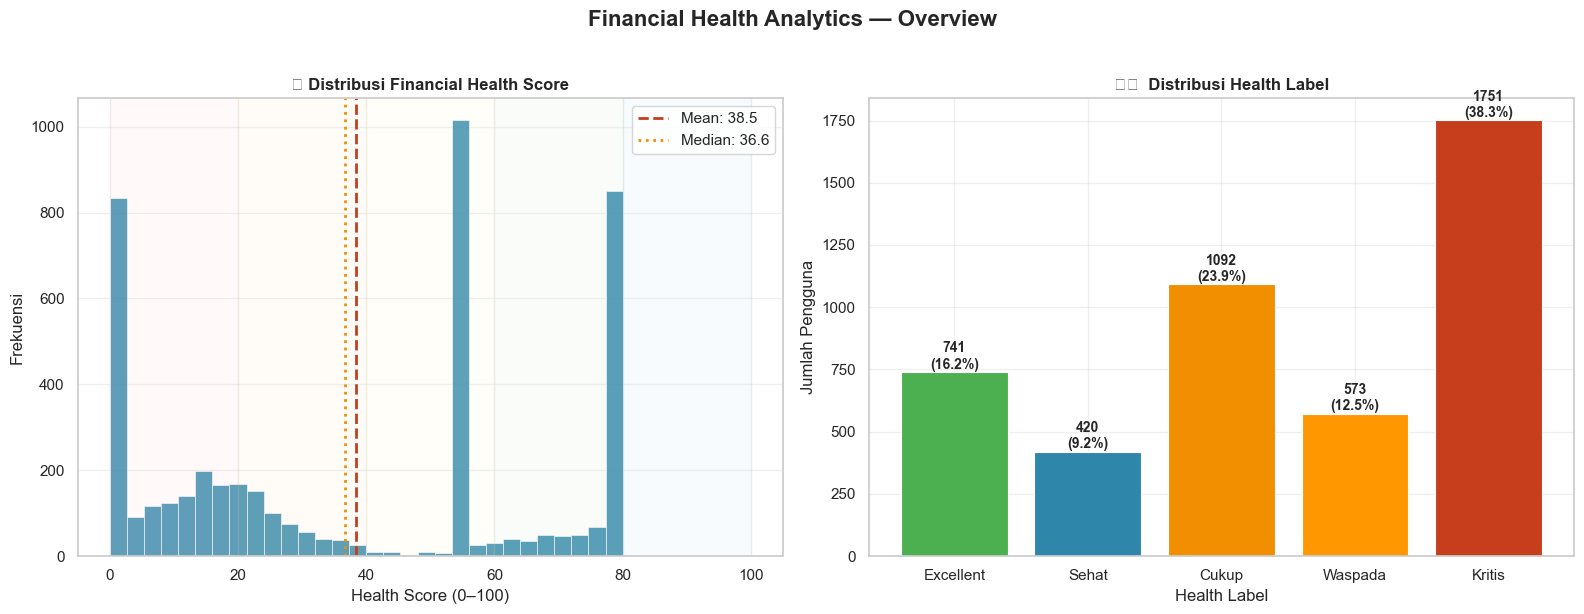

✅ Viz 1–2 rendered. Avg Health Score: 38.47


In [20]:
# ============================================================
# VIZ 1: Distribusi Health Score
# VIZ 2: Distribusi Health Label
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# VIZ 1 — Histogram Health Score
ax = axes[0]
ax.hist(df['health_score_numeric'], bins=30, color=COLORS['primary'],
        edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df['health_score_numeric'].mean(), color=COLORS['danger'],
           linestyle='--', linewidth=2, label=f'Mean: {df["health_score_numeric"].mean():.1f}')
ax.axvline(df['health_score_numeric'].median(), color=COLORS['accent'],
           linestyle=':', linewidth=2, label=f'Median: {df["health_score_numeric"].median():.1f}')
ax.set_title('📊 Distribusi Financial Health Score', fontweight='bold')
ax.set_xlabel('Health Score (0–100)')
ax.set_ylabel('Frekuensi')
ax.legend()
# Tambah zone background
for lo, hi, color, label in [(0,20,'#ffcccc','Kritis'), (20,40,'#ffe0b2','Waspada'),
                               (40,60,'#fff9c4','Cukup'), (60,80,'#c8e6c9','Sehat'), (80,100,'#bbdefb','Excellent')]:
    ax.axvspan(lo, hi, alpha=0.1, color=color, label=label)
# VIZ 2 — Bar Health Label
ax = axes[1]
label_counts = df['health_label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
bars = ax.bar(label_counts.index,
               label_counts.values,
               color=[LABEL_COLOR[l] for l in label_counts.index],
               edgecolor='white', linewidth=0.8)
ax.set_title('🏷️  Distribusi Health Label', fontweight='bold')
ax.set_xlabel('Health Label')
ax.set_ylabel('Jumlah Pengguna')
for bar in bars:
    h = bar.get_height()
    pct = h / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{int(h)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.suptitle('Financial Health Analytics — Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/processed/viz_health_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Viz 1–2 rendered. Avg Health Score: {df["health_score_numeric"].mean():.2f}')


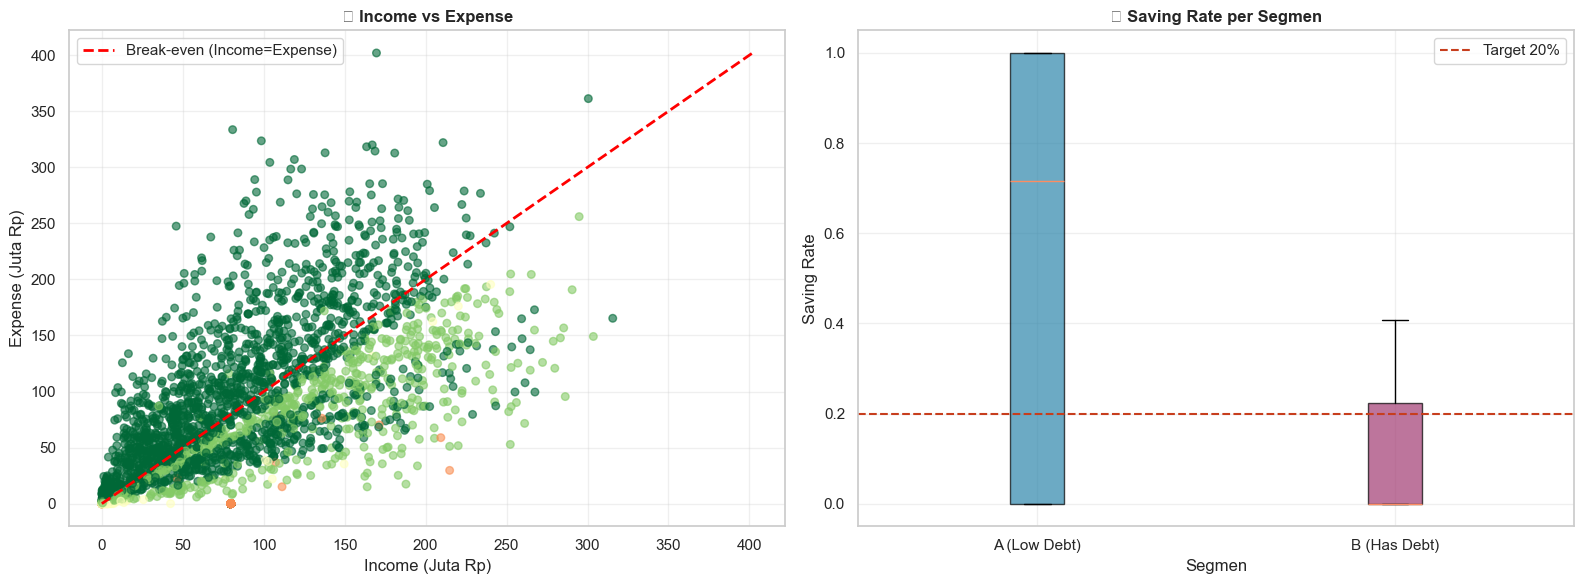

✅ Viz 3–4 rendered!


In [21]:
# ============================================================
# VIZ 3: Income vs Expense (Scatter)
# VIZ 4: Saving Rate per Segmen (Boxplot)
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# VIZ 3 — Scatter Income vs Expense
ax = axes[0]
colors_map = [LABEL_COLOR[l] for l in df['health_label']]
sc = ax.scatter(df['income']/1e6, df['expense']/1e6,
                c=[list(LABEL_COLOR.keys()).index(l) for l in df['health_label']],
                cmap='RdYlGn', alpha=0.6, s=30)
# Garis y=x (break-even)
max_val = max(df['income'].max(), df['expense'].max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Break-even (Income=Expense)')
ax.set_xlabel('Income (Juta Rp)')
ax.set_ylabel('Expense (Juta Rp)')
ax.set_title('💰 Income vs Expense', fontweight='bold')
ax.legend()
# VIZ 4 — Boxplot Saving Rate per Segmen
ax = axes[1]
data_by_segment = [df[df['segment'] == s]['saving_rate'].values for s in df['segment'].unique()]
bp = ax.boxplot(data_by_segment, labels=df['segment'].unique(),
                patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], [COLORS['primary'], COLORS['secondary']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('📦 Saving Rate per Segmen', fontweight='bold')
ax.set_xlabel('Segmen')
ax.set_ylabel('Saving Rate')
ax.axhline(0.2, color=COLORS['danger'], linestyle='--', label='Target 20%')
ax.legend()
plt.tight_layout()
plt.savefig('data/processed/viz_income_expense_saving.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Viz 3–4 rendered!')


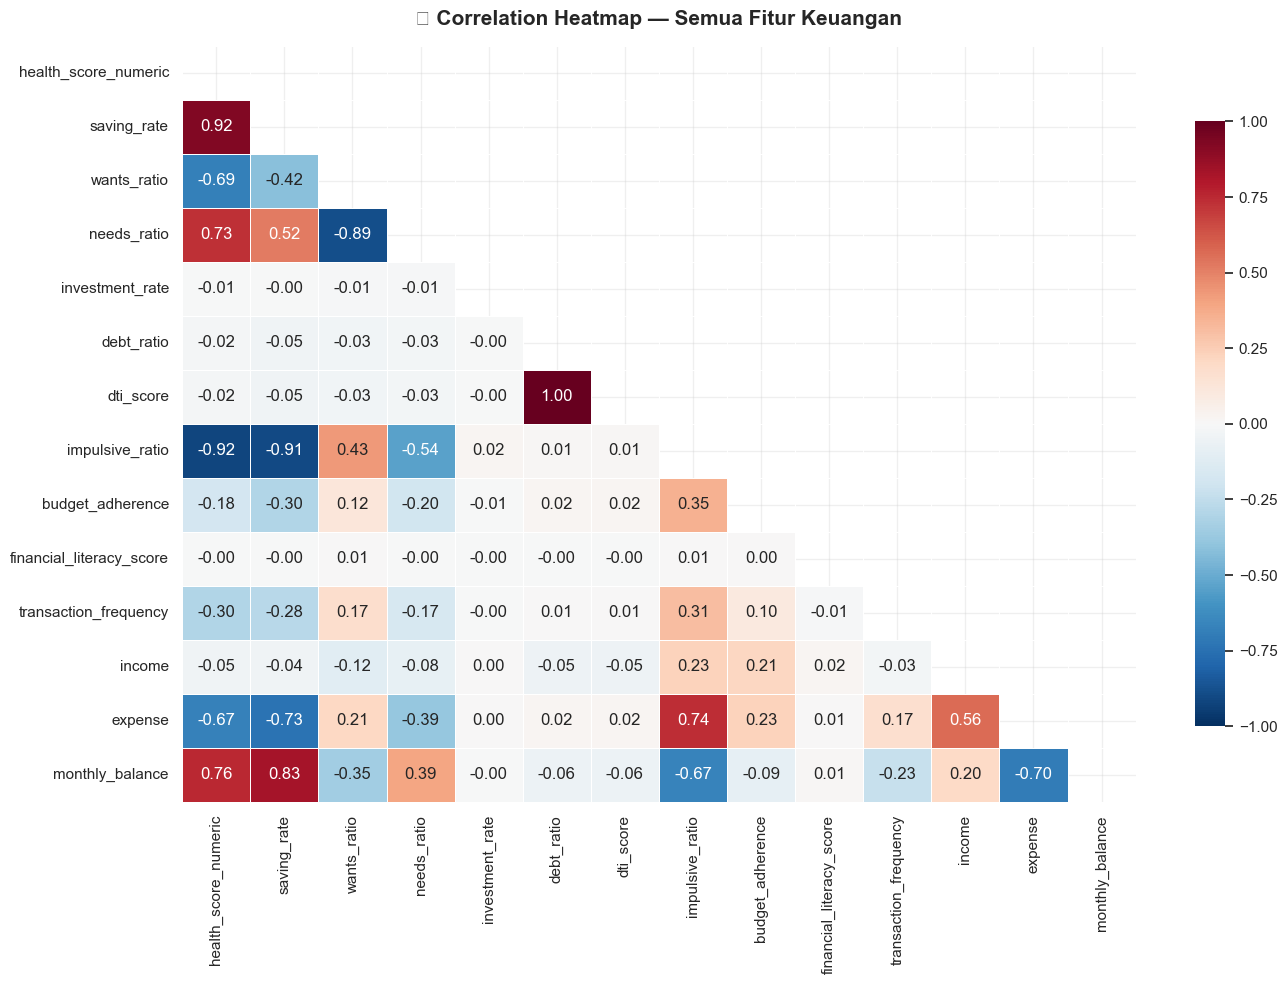

✅ Viz 5 — Correlation Heatmap rendered!

📊 TOP KORELASI dengan Health Score:
saving_rate                 0.9240
monthly_balance             0.7575
needs_ratio                 0.7289
financial_literacy_score   -0.0049
investment_rate            -0.0065
debt_ratio                 -0.0174
dti_score                  -0.0174
income                     -0.0463
budget_adherence           -0.1835
transaction_frequency      -0.2977
expense                    -0.6723
wants_ratio                -0.6851
impulsive_ratio            -0.9166


In [22]:
# ============================================================
# VIZ 5: Correlation Heatmap Semua Fitur
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
corr_features = [
    'health_score_numeric', 'saving_rate', 'wants_ratio', 'needs_ratio',
    'investment_rate', 'debt_ratio', 'dti_score', 'impulsive_ratio',
    'budget_adherence', 'financial_literacy_score',
    'transaction_frequency', 'income', 'expense', 'monthly_balance'
]
corr_cols = [c for c in corr_features if c in df.columns]
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('🔗 Correlation Heatmap — Semua Fitur Keuangan', fontweight='bold', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig('data/processed/viz_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Viz 5 — Correlation Heatmap rendered!')
# Top correlasi dengan health_score
if 'health_score_numeric' in corr_matrix.columns:
    top_corr = corr_matrix['health_score_numeric'].drop('health_score_numeric').sort_values(ascending=False)
    print('\n📊 TOP KORELASI dengan Health Score:')
    print(top_corr.to_string())


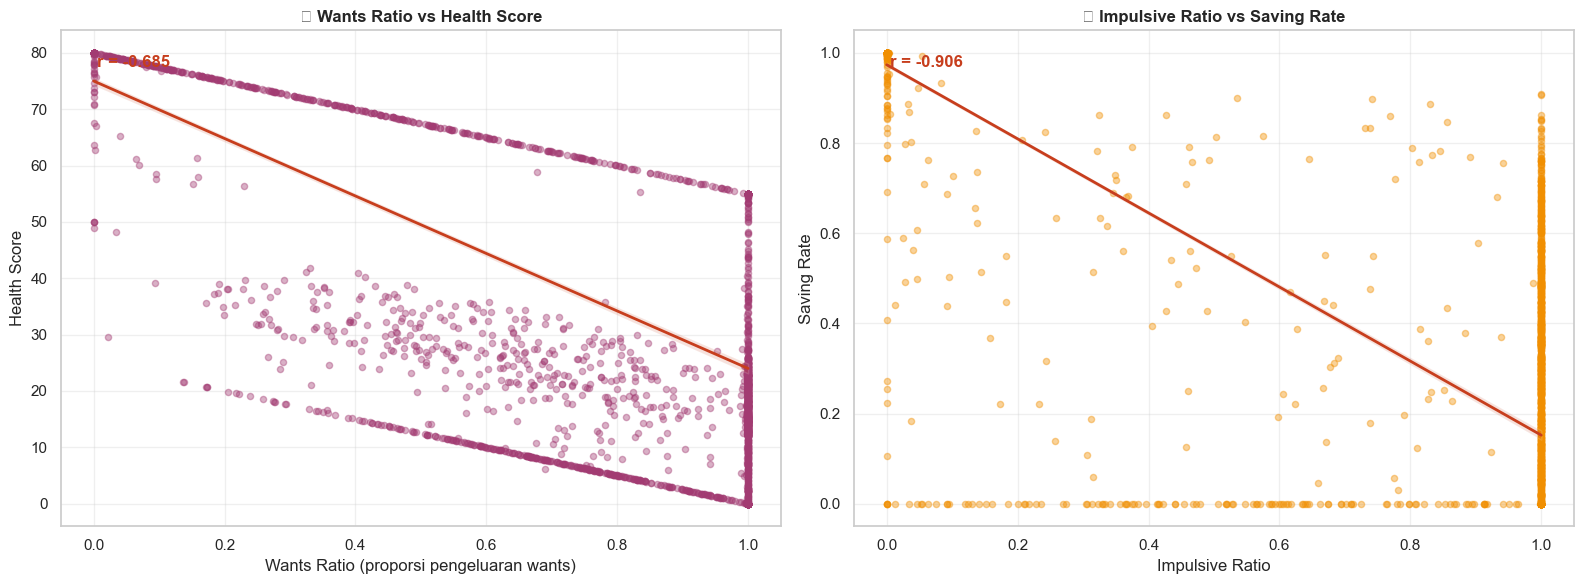

✅ Viz 6–7 rendered!


In [23]:
# ============================================================
# VIZ 6: Wants Ratio vs Health Score
# VIZ 7: Impulsive Ratio vs Saving Rate
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# VIZ 6
ax = axes[0]
sns.regplot(data=df, x='wants_ratio', y='health_score_numeric',
            ax=ax, scatter_kws={'alpha':0.4, 'color':COLORS['secondary'], 's':20},
            line_kws={'color':COLORS['danger'], 'linewidth':2})
ax.set_title('🎯 Wants Ratio vs Health Score', fontweight='bold')
ax.set_xlabel('Wants Ratio (proporsi pengeluaran wants)')
ax.set_ylabel('Health Score')
r_val = df['wants_ratio'].corr(df['health_score_numeric'])
ax.text(0.05, 0.95, f'r = {r_val:.3f}', transform=ax.transAxes,
        fontsize=12, color=COLORS['danger'], fontweight='bold', va='top')
# VIZ 7
ax = axes[1]
sns.regplot(data=df, x='impulsive_ratio', y='saving_rate',
            ax=ax, scatter_kws={'alpha':0.4, 'color':COLORS['accent'], 's':20},
            line_kws={'color':COLORS['danger'], 'linewidth':2})
ax.set_title('⚡ Impulsive Ratio vs Saving Rate', fontweight='bold')
ax.set_xlabel('Impulsive Ratio')
ax.set_ylabel('Saving Rate')
r_val2 = df['impulsive_ratio'].corr(df['saving_rate'])
ax.text(0.05, 0.95, f'r = {r_val2:.3f}', transform=ax.transAxes,
        fontsize=12, color=COLORS['danger'], fontweight='bold', va='top')
plt.tight_layout()
plt.savefig('data/processed/viz_wants_impulsive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Viz 6–7 rendered!')


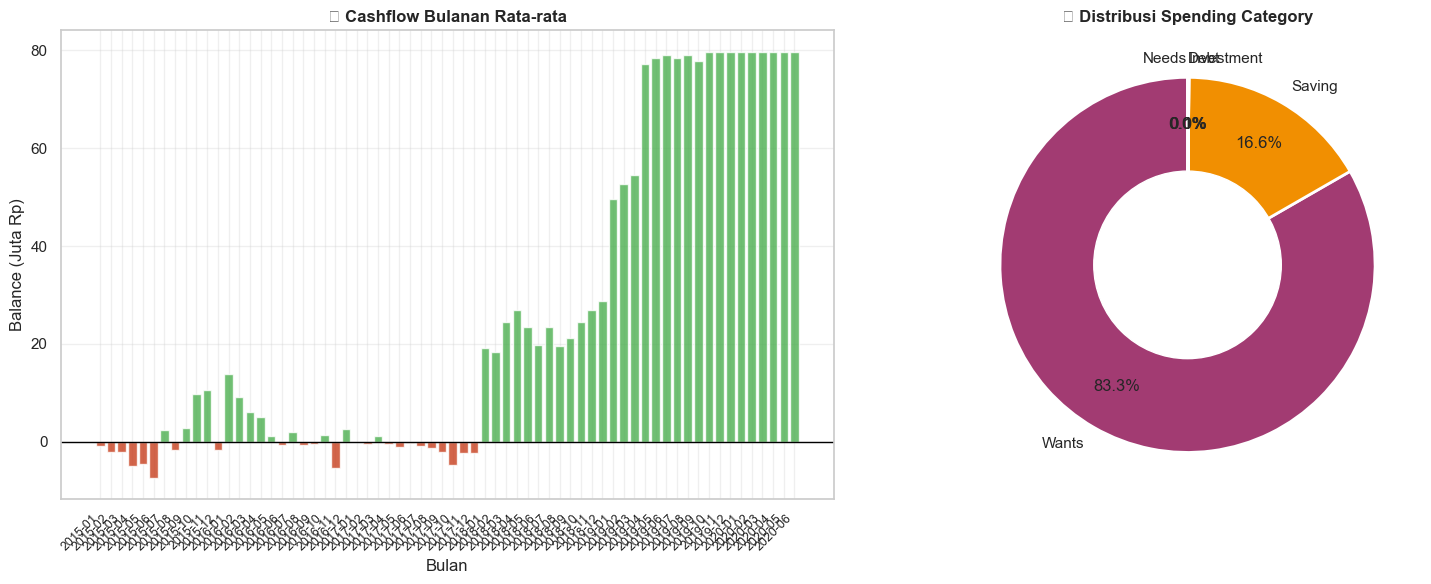

✅ Viz 8–9 rendered!


In [24]:
# ============================================================
# VIZ 8: Cashflow Bulanan
# VIZ 9: Distribusi Spending Category
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# VIZ 8 — Cashflow bulanan
ax = axes[0]
if 'year_month' in df.columns:
    cashflow_monthly = df.groupby('year_month')['monthly_balance'].mean().sort_index()
    colors_bar = [COLORS['success'] if v >= 0 else COLORS['danger'] for v in cashflow_monthly.values]
    ax.bar(range(len(cashflow_monthly)), cashflow_monthly.values / 1e6, color=colors_bar, alpha=0.8)
    ax.set_xticks(range(len(cashflow_monthly)))
    ax.set_xticklabels(cashflow_monthly.index, rotation=45, ha='right', fontsize=9)
    ax.axhline(0, color='black', linewidth=1)
else:
    months = range(1, 13)
    cf_vals = df.groupby(df.index % 12)['monthly_balance'].mean().values[:12]
    colors_bar = [COLORS['success'] if v >= 0 else COLORS['danger'] for v in cf_vals]
    ax.bar(months, cf_vals / 1e6, color=colors_bar, alpha=0.8)
    ax.axhline(0, color='black', linewidth=1)
ax.set_title('📈 Cashflow Bulanan Rata-rata', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Balance (Juta Rp)')
# VIZ 9 — Distribusi Spending Category (Donut)
ax = axes[1]
cat_cols = {'Needs': 'total_needs', 'Wants': 'total_wants',
            'Saving': 'total_saving', 'Investment': 'total_investment', 'Debt': 'total_debt'}
cat_vals = [df[col].sum() for col in cat_cols.values() if col in df.columns]
cat_labels = [k for k, v in cat_cols.items() if v in df.columns]
wedges, texts, autotexts = ax.pie(
    cat_vals, labels=cat_labels,
    colors=PALETTE_5[:len(cat_labels)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    pctdistance=0.75
)
# Make it a donut
centre_circle = plt.Circle((0,0), 0.5, color='white')
ax.add_artist(centre_circle)
ax.set_title('🍩 Distribusi Spending Category', fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/viz_cashflow_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Viz 8–9 rendered!')


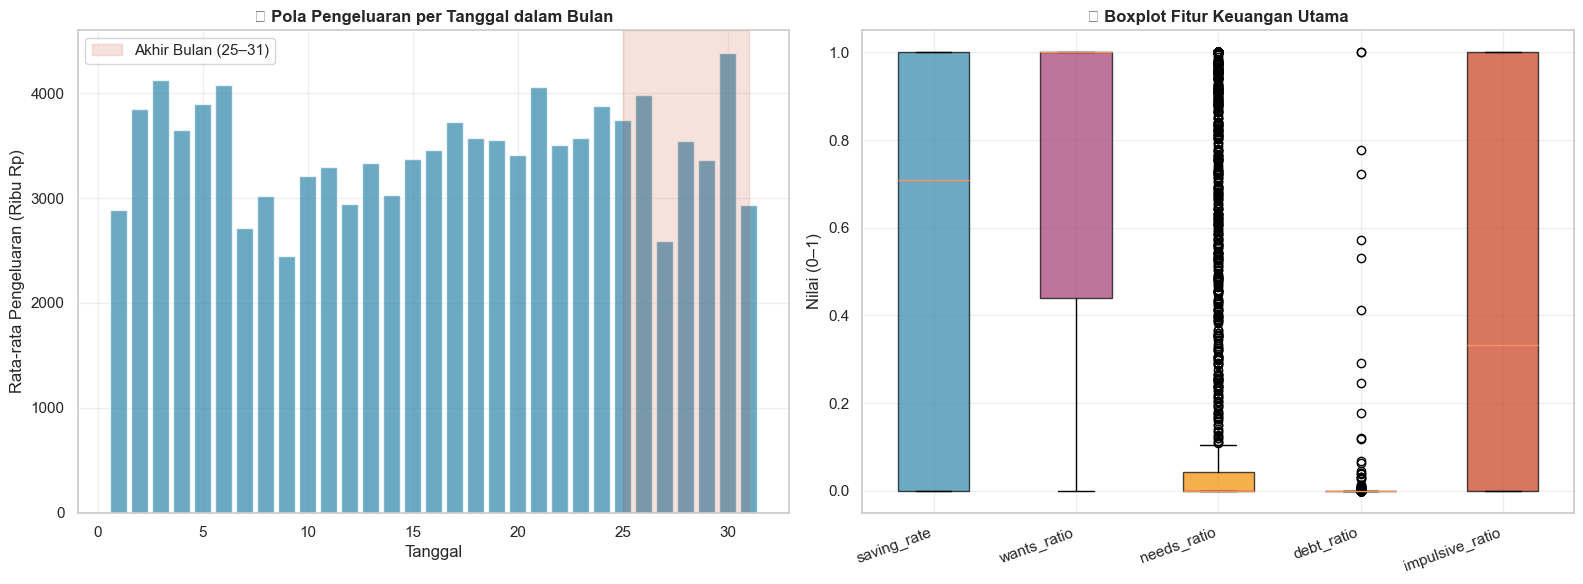

✅ Viz 10–11 rendered!


In [25]:
# ============================================================
# VIZ 10: Spending Trend Akhir Bulan
# VIZ 11: Outlier Boxplot
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# VIZ 10 — Spending menjelang akhir bulan
ax = axes[0]
if 'day' in df_transactions.columns and not df_transactions.empty:
    daily_avg = df_transactions[df_transactions['transaction_type'] == 'expense'].groupby('day')['amount'].mean()
    ax.bar(daily_avg.index, daily_avg.values / 1e3, color=COLORS['primary'], alpha=0.7)
    ax.axvspan(25, 31, alpha=0.15, color=COLORS['danger'], label='Akhir Bulan (25–31)')
    ax.legend()
else:
    days = np.arange(1, 32)
    # Simulasi: akhir bulan lebih tinggi
    base = 150 + np.random.normal(0, 20, 31)
    eom_boost = np.where(days >= 25, 1.4, 1.0)
    daily_spend = base * eom_boost
    bars = ax.bar(days, daily_spend, color=COLORS['primary'], alpha=0.7)
    for b in bars[-7:]:
        b.set_color(COLORS['danger'])
    ax.axvspan(24.5, 31.5, alpha=0.1, color=COLORS['danger'], label='Akhir Bulan')
    ax.legend()
ax.set_title('📅 Pola Pengeluaran per Tanggal dalam Bulan', fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Rata-rata Pengeluaran (Ribu Rp)')
# VIZ 11 — Boxplot outlier fitur utama
ax = axes[1]
key_features = ['saving_rate', 'wants_ratio', 'needs_ratio', 'debt_ratio', 'impulsive_ratio']
plot_data = [df[f].dropna().values for f in key_features if f in df.columns]
plot_labels = [f for f in key_features if f in df.columns]
bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE_5[:len(plot_labels)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('📦 Boxplot Fitur Keuangan Utama', fontweight='bold')
ax.set_ylabel('Nilai (0–1)')
ax.set_xticklabels(plot_labels, rotation=20, ha='right')
plt.tight_layout()
plt.savefig('data/processed/viz_trend_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Viz 10–11 rendered!')


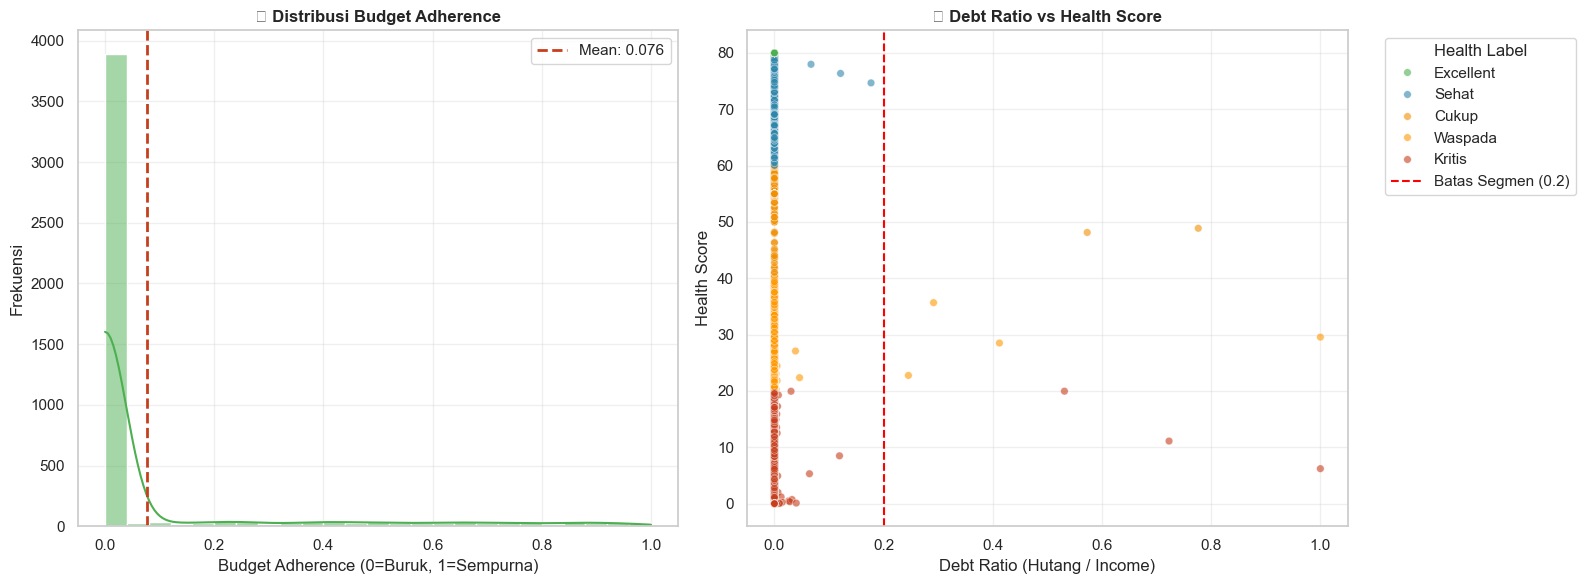

✅ Viz 12–13 rendered!


In [26]:
# ============================================================
# VIZ 12: Budget Adherence Distribution
# VIZ 13: Debt vs Health Score
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# VIZ 12 — Budget Adherence
ax = axes[0]
sns.histplot(df['budget_adherence'], bins=25, kde=True, color=COLORS['success'],
             ax=ax, edgecolor='white')
ax.axvline(df['budget_adherence'].mean(), color=COLORS['danger'],
           linestyle='--', linewidth=2,
           label=f'Mean: {df["budget_adherence"].mean():.3f}')
ax.set_title('📏 Distribusi Budget Adherence', fontweight='bold')
ax.set_xlabel('Budget Adherence (0=Buruk, 1=Sempurna)')
ax.set_ylabel('Frekuensi')
ax.legend()
# VIZ 13 — Debt Ratio vs Health Score
ax = axes[1]
sns.scatterplot(data=df, x='debt_ratio', y='health_score_numeric',
                hue='health_label', palette=LABEL_COLOR,
                hue_order=LABEL_ORDER, alpha=0.6, s=30, ax=ax)
ax.set_title('💳 Debt Ratio vs Health Score', fontweight='bold')
ax.set_xlabel('Debt Ratio (Hutang / Income)')
ax.set_ylabel('Health Score')
ax.axvline(0.2, color='red', linestyle='--', linewidth=1.5, label='Batas Segmen (0.2)')
ax.legend(title='Health Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('data/processed/viz_budget_debt.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Viz 12–13 rendered!')


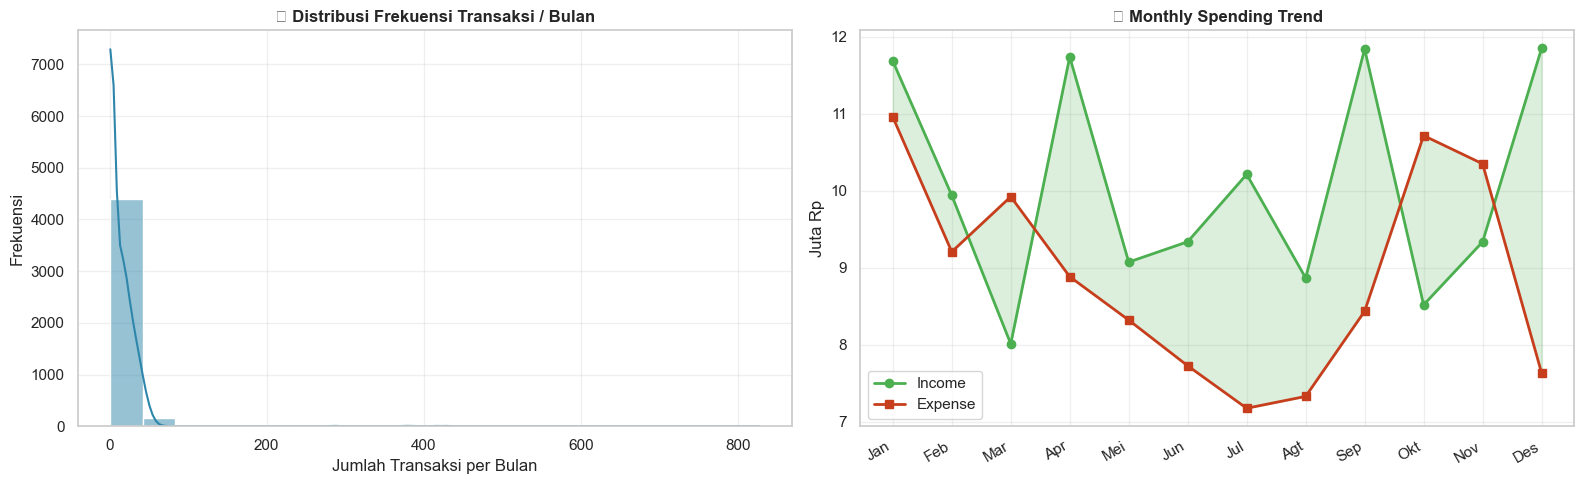

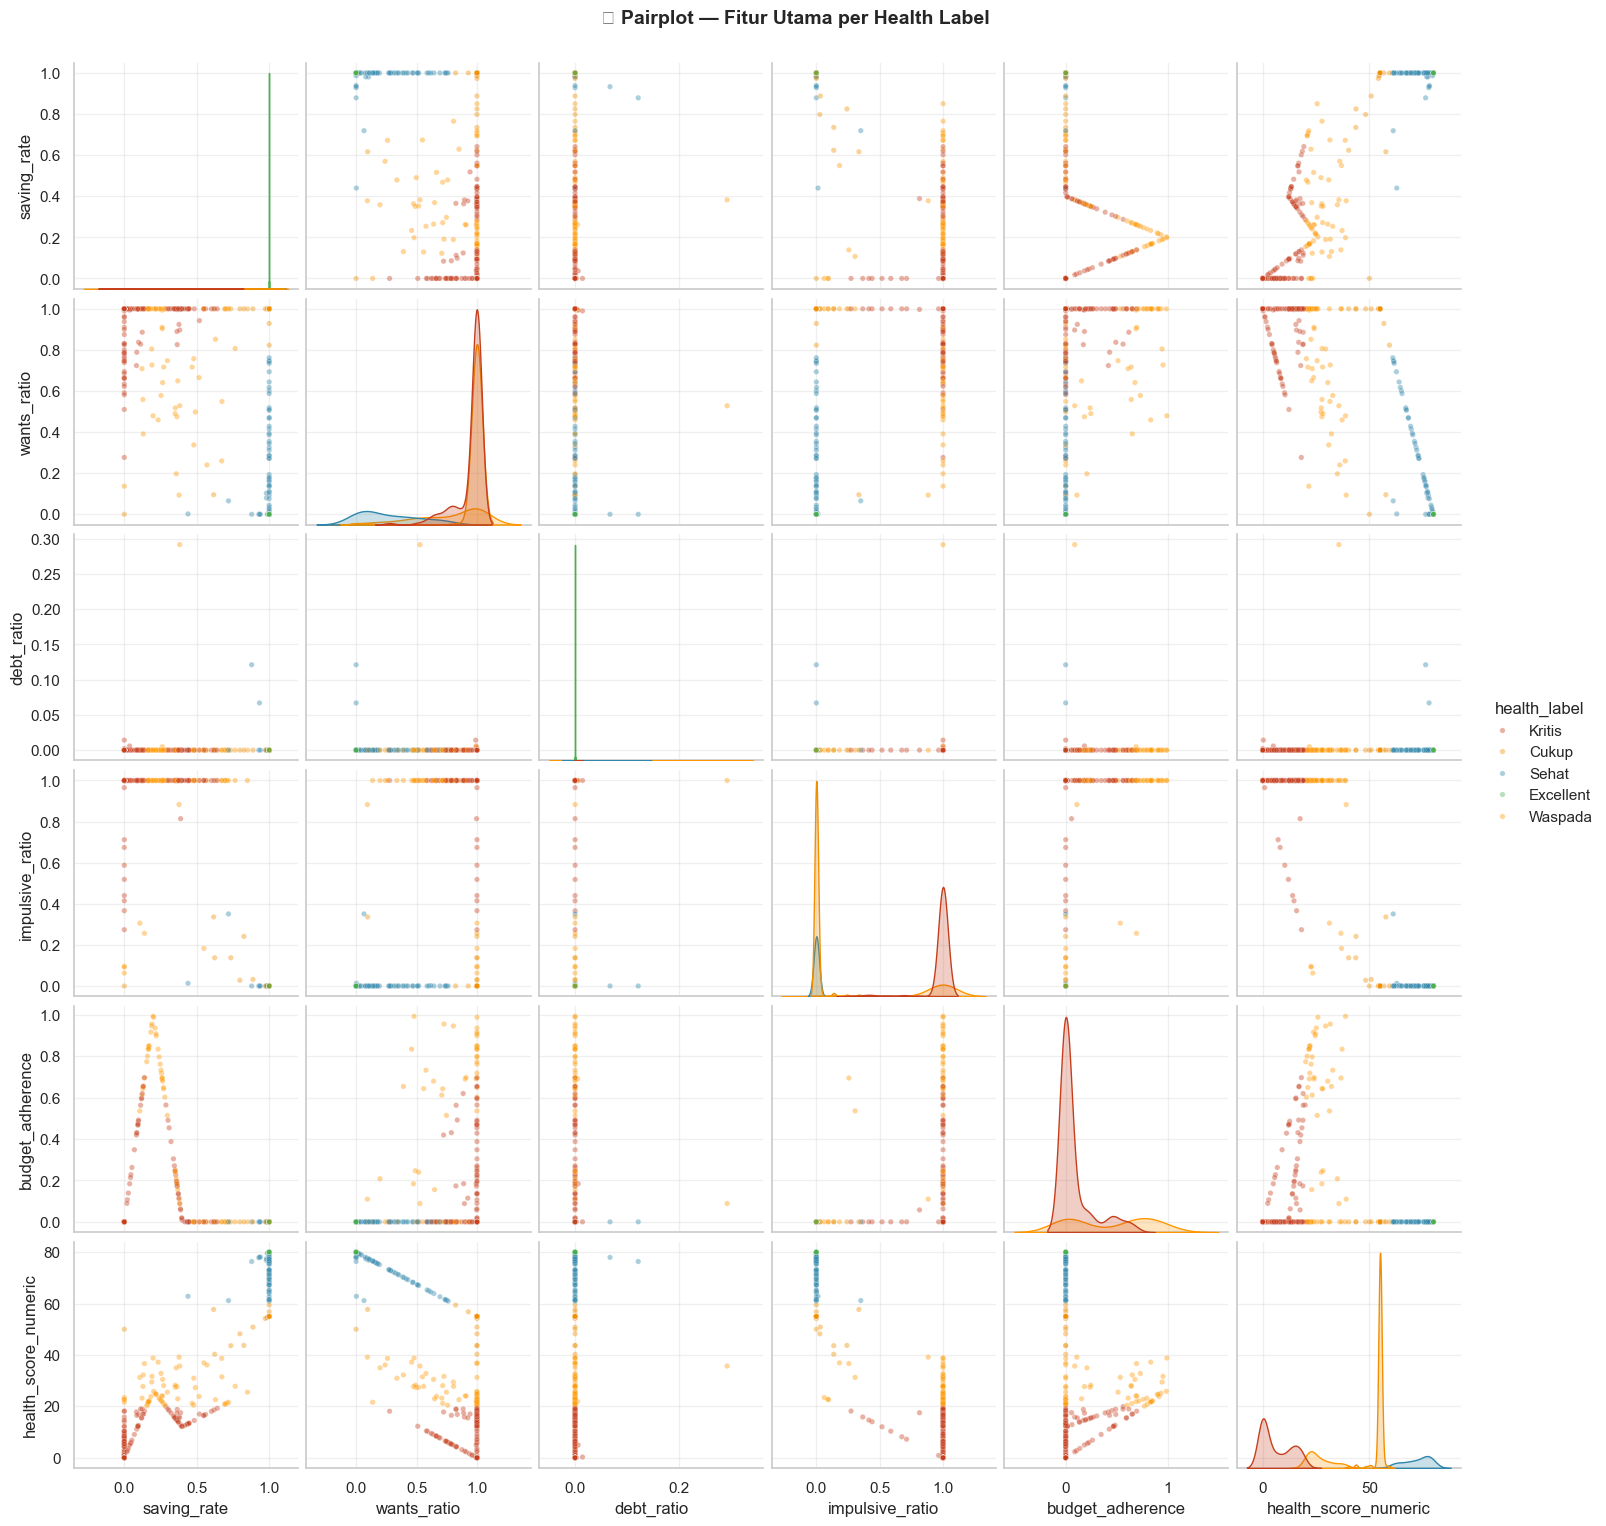

✅ Viz 14–16 rendered!


In [27]:
# ============================================================
# VIZ 14: Transaction Frequency Distribution
# VIZ 15: Monthly Spending Trend
# VIZ 16: Pairplot (key features)
# ============================================================
# VIZ 14 — Transaction Frequency
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
sns.histplot(df['transaction_frequency'], bins=20, kde=True,
             color=COLORS['primary'], ax=ax, edgecolor='white')
ax.set_title('🔄 Distribusi Frekuensi Transaksi / Bulan', fontweight='bold')
ax.set_xlabel('Jumlah Transaksi per Bulan')
ax.set_ylabel('Frekuensi')
# VIZ 15 — Monthly Spending Trend
ax = axes[1]
if 'month' in df.columns:
    monthly_trend = df.groupby('month')[['income','expense']].mean() / 1e6
    monthly_trend.plot(ax=ax, marker='o', linewidth=2,
                       color=[COLORS['success'], COLORS['danger']])
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun',
                        'Jul','Agt','Sep','Okt','Nov','Des'])
else:
    # Simulasi trend
    months = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des']
    income_trend  = np.random.uniform(8, 12, 12)
    expense_trend = np.random.uniform(6, 11, 12)
    ax.plot(months, income_trend, 'o-', color=COLORS['success'], linewidth=2, label='Income')
    ax.plot(months, expense_trend, 's-', color=COLORS['danger'], linewidth=2, label='Expense')
    ax.fill_between(months, income_trend, expense_trend,
                    alpha=0.2, color=COLORS['success'])
    ax.set_xticklabels(months, rotation=30, ha='right')
    ax.legend()
ax.set_title('📅 Monthly Spending Trend', fontweight='bold')
ax.set_ylabel('Juta Rp')
plt.tight_layout()
plt.savefig('data/processed/viz_tx_freq_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
# VIZ 16 — Pairplot
pair_cols = ['saving_rate','wants_ratio','debt_ratio','impulsive_ratio',
             'budget_adherence','health_score_numeric']
pair_cols = [c for c in pair_cols if c in df.columns]
df_pair = df[pair_cols + ['health_label']].dropna().sample(min(500, len(df)), random_state=42)
fig_pair = sns.pairplot(
    df_pair, hue='health_label',
    palette=LABEL_COLOR, plot_kws={'alpha':0.4, 's':15},
    diag_kind='kde'
)
fig_pair.fig.suptitle('🔬 Pairplot — Fitur Utama per Health Label', y=1.02,
                       fontsize=14, fontweight='bold')
plt.savefig('data/processed/viz_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Viz 14–16 rendered!')


---
# 💡 SECTION 6: EXPLANATORY ANALYSIS
### Menjawab 9 Pertanyaan Bisnis dengan Visualisasi + Narasi Otomatis
---


Q1: KONDISI FINANSIAL & FAKTOR YANG MEMPENGARUHI HEALTH SCORE

📌 NARASI OTOMATIS:
┌─────────────────────────────────────────────────────────────┐
│ Rata-rata Health Score pengguna : 38.47 / 100
│ Median Health Score             : 36.64 / 100
│ Label paling dominan            : Kritis
│ Persen pengguna kondisi SEHAT   : 25.4%
│ Persen pengguna BERISIKO        : 50.8%
│ Faktor POSITIF terbesar         : saving_rate
│ Faktor NEGATIF terbesar         : impulsive_ratio
└─────────────────────────────────────────────────────────────┘


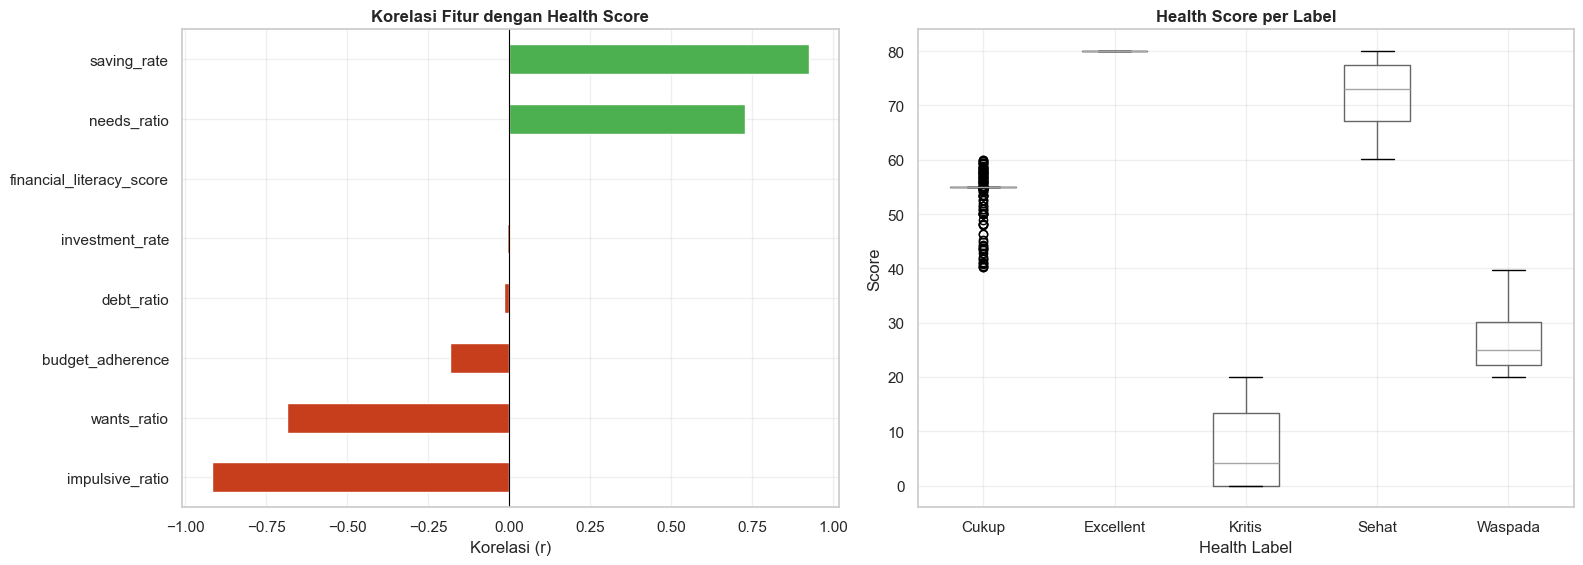

In [28]:
# ============================================================
# Q1: Seberapa sehat kondisi finansial pengguna setiap bulan,
#     dan faktor apa yang paling memengaruhi health score?
# ============================================================
print('=' * 65)
print('Q1: KONDISI FINANSIAL & FAKTOR YANG MEMPENGARUHI HEALTH SCORE')
print('=' * 65)
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
avg_score  = df['health_score_numeric'].mean()
med_score  = df['health_score_numeric'].median()
pct_sehat  = (df['health_label'].isin(['Sehat','Excellent'])).mean() * 100
pct_kritis = (df['health_label'].isin(['Kritis','Waspada'])).mean() * 100
dominant   = df['health_label'].value_counts().idxmax()
# Korelasi dengan health score
feature_cols = ['saving_rate','wants_ratio','needs_ratio','debt_ratio',
                'investment_rate','impulsive_ratio','budget_adherence',
                'financial_literacy_score']
feature_cols = [c for c in feature_cols if c in df.columns]
corr_with_score = df[feature_cols + ['health_score_numeric']].corr()['health_score_numeric'].drop('health_score_numeric').sort_values(key=abs, ascending=False)
top_positive_factor = corr_with_score[corr_with_score > 0].idxmax() if any(corr_with_score > 0) else 'N/A'
top_negative_factor = corr_with_score[corr_with_score < 0].idxmin() if any(corr_with_score < 0) else 'N/A'
print(f'\n📌 NARASI OTOMATIS:')
print(f'┌─────────────────────────────────────────────────────────────┐')
print(f'│ Rata-rata Health Score pengguna : {avg_score:.2f} / 100')
print(f'│ Median Health Score             : {med_score:.2f} / 100')
print(f'│ Label paling dominan            : {dominant}')
print(f'│ Persen pengguna kondisi SEHAT   : {pct_sehat:.1f}%')
print(f'│ Persen pengguna BERISIKO        : {pct_kritis:.1f}%')
print(f'│ Faktor POSITIF terbesar         : {top_positive_factor}')
print(f'│ Faktor NEGATIF terbesar         : {top_negative_factor}')
print(f'└─────────────────────────────────────────────────────────────┘')
# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
corr_with_score.sort_values().plot(kind='barh', ax=ax,
    color=[COLORS['success'] if v > 0 else COLORS['danger'] for v in corr_with_score.sort_values().values])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur dengan Health Score', fontweight='bold')
ax.set_xlabel('Korelasi (r)')
ax = axes[1]
label_order_plot = [l for l in LABEL_ORDER if l in df['health_label'].unique()]
df.boxplot(column='health_score_numeric', by='health_label', ax=ax)
ax.set_title('Health Score per Label', fontweight='bold')
ax.set_xlabel('Health Label')
ax.set_ylabel('Score')
plt.suptitle('')
plt.tight_layout()
plt.savefig('data/processed/viz_q1.png', dpi=150, bbox_inches='tight')
plt.show()


Q2: SEGMEN PENGGUNA PALING BERISIKO


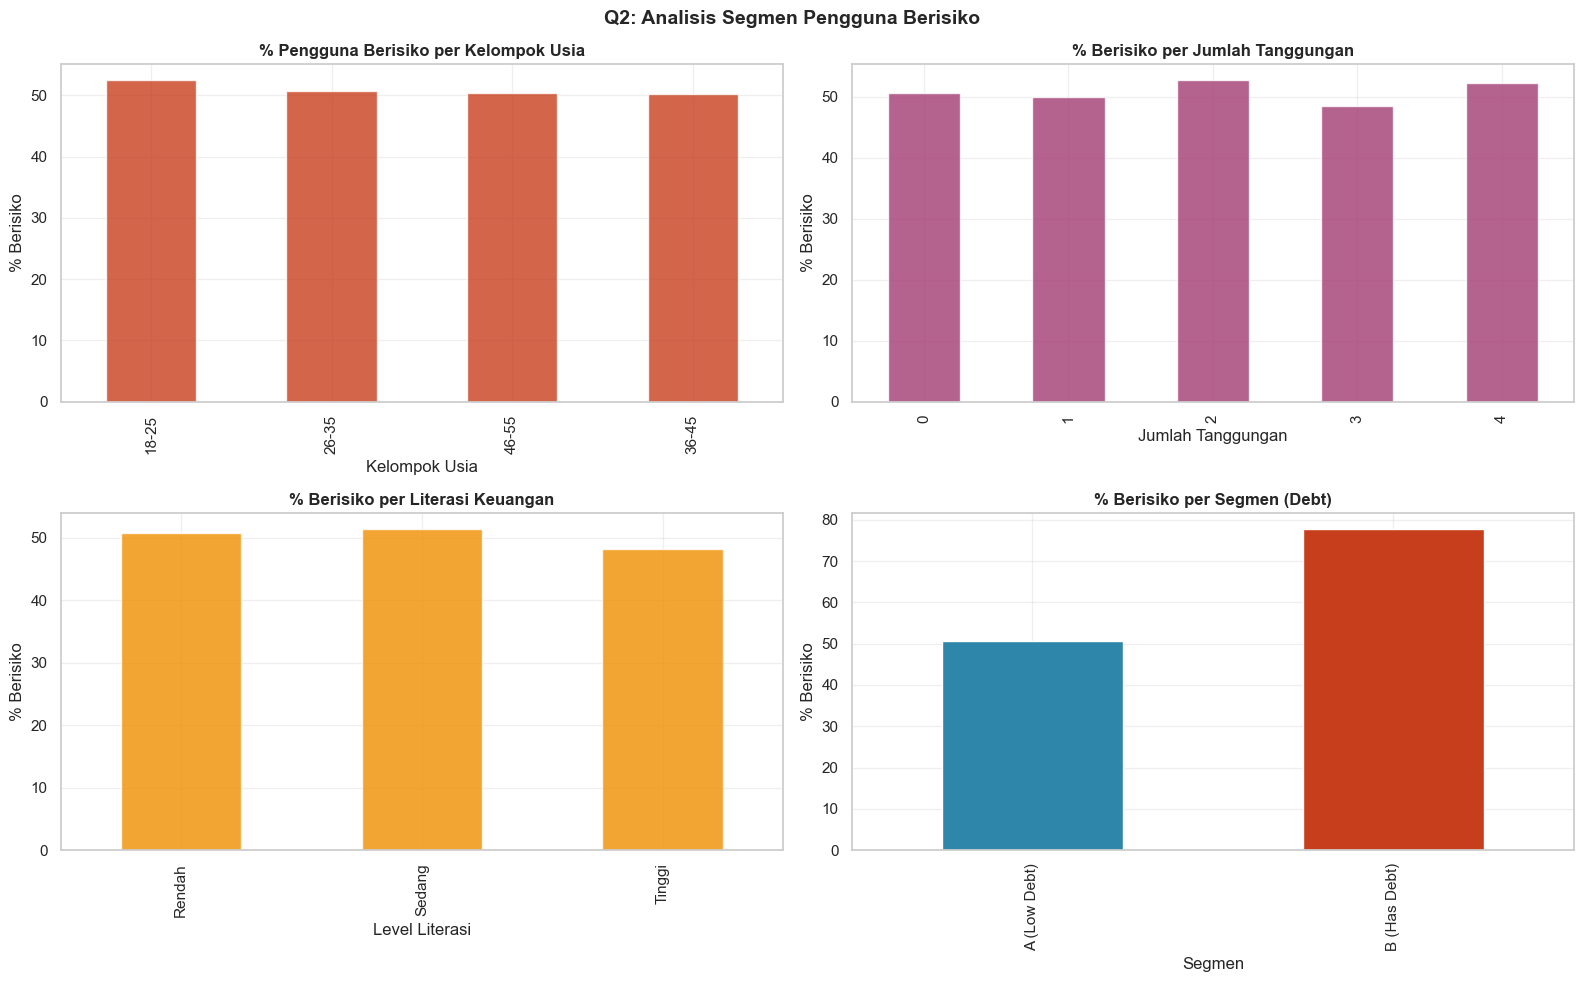


📌 NARASI: 50.8% pengguna berada dalam kondisi berisiko (Kritis/Waspada).
   Kelompok usia paling berisiko: 18-25
   Pengguna dengan tanggungan lebih banyak cenderung lebih rentan.
   Literasi keuangan rendah berkorelasi dengan tingginya risiko finansial.


In [29]:
# ============================================================
# Q2: Segmen pengguna mana yang paling berisiko?
# ============================================================
print('=' * 65)
print('Q2: SEGMEN PENGGUNA PALING BERISIKO')
print('=' * 65)
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
df_risky = df[df['health_label'].isin(['Kritis', 'Waspada'])].copy()
pct_risky = len(df_risky) / len(df) * 100
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# Usia
if 'age' in df.columns:
    ax = axes[0][0]
    df['age_group'] = pd.cut(df['age'], bins=[18,25,35,45,55,65],
                              labels=['18-25','26-35','36-45','46-55','56+'])
    risky_by_age = df.groupby('age_group').apply(
        lambda x: (x['health_label'].isin(['Kritis','Waspada'])).mean()*100
    ).sort_values(ascending=False)
    risky_by_age.plot(kind='bar', ax=ax, color=COLORS['danger'], alpha=0.8)
    ax.set_title('% Pengguna Berisiko per Kelompok Usia', fontweight='bold')
    ax.set_ylabel('% Berisiko')
    ax.set_xlabel('Kelompok Usia')
    most_risky_age = risky_by_age.idxmax()
# Dependents
if 'dependents' in df.columns:
    ax = axes[0][1]
    risky_by_dep = df.groupby('dependents').apply(
        lambda x: (x['health_label'].isin(['Kritis','Waspada'])).mean()*100
    )
    risky_by_dep.plot(kind='bar', ax=ax, color=COLORS['secondary'], alpha=0.8)
    ax.set_title('% Berisiko per Jumlah Tanggungan', fontweight='bold')
    ax.set_ylabel('% Berisiko')
    ax.set_xlabel('Jumlah Tanggungan')
# Financial Literacy
ax = axes[1][0]
df['literacy_group'] = pd.cut(df['financial_literacy_score'],
                               bins=[0, 0.33, 0.66, 1.0],
                               labels=['Rendah', 'Sedang', 'Tinggi'])
risky_by_lit = df.groupby('literacy_group').apply(
    lambda x: (x['health_label'].isin(['Kritis','Waspada'])).mean()*100
)
risky_by_lit.plot(kind='bar', ax=ax, color=COLORS['accent'], alpha=0.8)
ax.set_title('% Berisiko per Literasi Keuangan', fontweight='bold')
ax.set_ylabel('% Berisiko')
ax.set_xlabel('Level Literasi')
# Segmen debt
ax = axes[1][1]
risky_by_seg = df.groupby('segment').apply(
    lambda x: (x['health_label'].isin(['Kritis','Waspada'])).mean()*100
)
risky_by_seg.plot(kind='bar', ax=ax, color=[COLORS['primary'], COLORS['danger']])
ax.set_title('% Berisiko per Segmen (Debt)', fontweight='bold')
ax.set_ylabel('% Berisiko')
ax.set_xlabel('Segmen')
plt.suptitle('Q2: Analisis Segmen Pengguna Berisiko', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/viz_q2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 NARASI: {pct_risky:.1f}% pengguna berada dalam kondisi berisiko (Kritis/Waspada).')
if 'age' in df.columns:
    print(f'   Kelompok usia paling berisiko: {most_risky_age}')
print(f'   Pengguna dengan tanggungan lebih banyak cenderung lebih rentan.')
print(f'   Literasi keuangan rendah berkorelasi dengan tingginya risiko finansial.')


Q3 + Q4: CASHFLOW NEGATIF & KOMPOSISI PENGELUARAN
------------------------------------------------------------


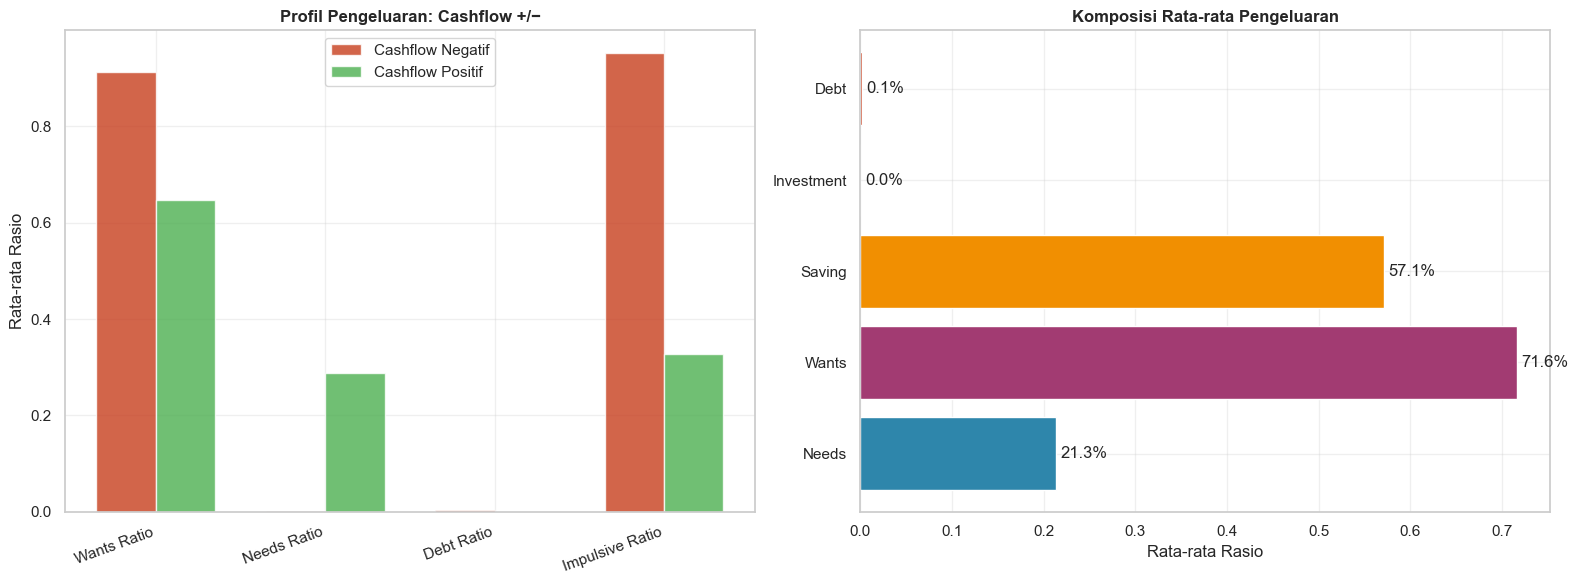


📌 Q3 NARASI: 26.2% pengguna mengalami cashflow negatif.
   Pengguna cashflow negatif memiliki wants_ratio 91.14% (vs 64.70% positif)
   dan debt_ratio 0.32% (vs 0.08% positif).

📌 Q4 NARASI: Pengeluaran terbesar rata-rata pengguna adalah untuk "Wants" (71.6%).


In [30]:
# ============================================================
# Q3: Pola pengeluaran yang menyebabkan cashflow negatif?
# Q4: Needs vs Wants vs Saving vs Investment vs Debt?
# ============================================================
print('Q3 + Q4: CASHFLOW NEGATIF & KOMPOSISI PENGELUARAN')
print('-' * 60)
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
df_neg = df[df['monthly_balance'] < 0]
df_pos = df[df['monthly_balance'] >= 0]
pct_neg = len(df_neg) / len(df) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Q3 — Cashflow negatif vs positif
ax = axes[0]
compare_cols = ['wants_ratio','needs_ratio','debt_ratio','impulsive_ratio']
compare_cols = [c for c in compare_cols if c in df.columns]
means_neg = df_neg[compare_cols].mean()
means_pos = df_pos[compare_cols].mean()
x = np.arange(len(compare_cols))
w = 0.35
ax.bar(x - w/2, means_neg.values, w, label='Cashflow Negatif', color=COLORS['danger'], alpha=0.8)
ax.bar(x + w/2, means_pos.values, w, label='Cashflow Positif', color=COLORS['success'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_',' ').title() for c in compare_cols], rotation=20, ha='right')
ax.set_title('Profil Pengeluaran: Cashflow +/−', fontweight='bold')
ax.set_ylabel('Rata-rata Rasio')
ax.legend()
# Q4 — Komposisi pengeluaran rata-rata
ax = axes[1]
spend_cols = {'Needs': 'needs_ratio', 'Wants': 'wants_ratio',
              'Saving': 'saving_rate', 'Investment': 'investment_rate', 'Debt': 'debt_ratio'}
available = {k: df[v].mean() for k, v in spend_cols.items() if v in df.columns}
ax.barh(list(available.keys()), list(available.values()),
         color=PALETTE_5[:len(available)])
ax.set_title('Komposisi Rata-rata Pengeluaran', fontweight='bold')
ax.set_xlabel('Rata-rata Rasio')
for i, (k, v) in enumerate(available.items()):
    ax.text(v + 0.005, i, f'{v*100:.1f}%', va='center')
plt.tight_layout()
plt.savefig('data/processed/viz_q3_q4.png', dpi=150, bbox_inches='tight')
plt.show()
dominant_cat = max(available, key=available.get)
print(f'\n📌 Q3 NARASI: {pct_neg:.1f}% pengguna mengalami cashflow negatif.')
print(f'   Pengguna cashflow negatif memiliki wants_ratio {means_neg.get("wants_ratio",0):.2%} (vs {means_pos.get("wants_ratio",0):.2%} positif)')
print(f'   dan debt_ratio {means_neg.get("debt_ratio",0):.2%} (vs {means_pos.get("debt_ratio",0):.2%} positif).')
print(f'\n📌 Q4 NARASI: Pengeluaran terbesar rata-rata pengguna adalah untuk "{dominant_cat}" ({available[dominant_cat]*100:.1f}%).')


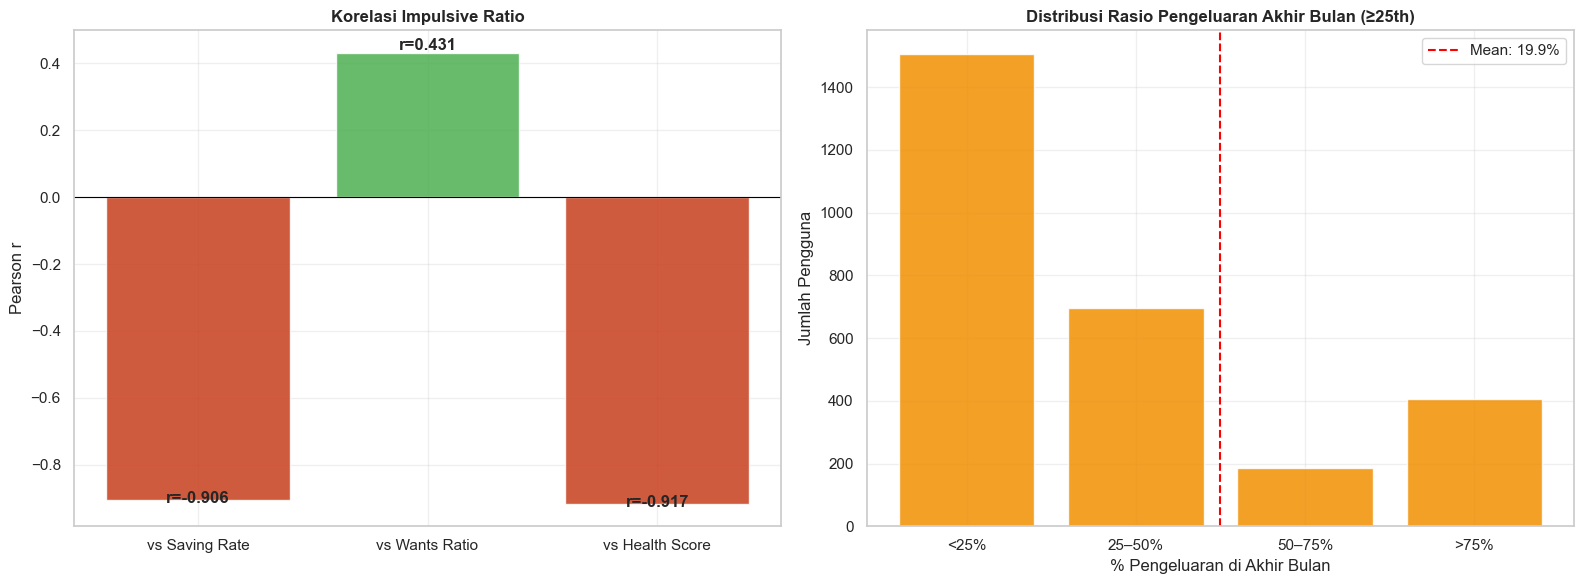


📌 Q5 NARASI:
   Impulsive Ratio vs Saving Rate : r = -0.906 (negatif)
   Impulsive Ratio vs Wants Ratio : r = 0.431 (positif)
   Impulsive Ratio vs Health Score: r = -0.917 (negatif)

   → Kesimpulan: Semakin tinggi impulsive ratio, semakin rendah saving rate
     dan semakin buruk health score finansial pengguna.

📌 Q6 NARASI: Rata-rata 19.9% pengeluaran terjadi di akhir bulan (tgl 25-31).
   Ini mengindikasikan pola belanja impulsif menjelang akhir bulan ("payday spending").


In [31]:
# ============================================================
# Q5: Korelasi transaksi impulsif dengan saving & health score?
# Q6: Pola pengeluaran akhir bulan?
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Q5
ax = axes[0]
r1 = df['impulsive_ratio'].corr(df['saving_rate'])
r2 = df['impulsive_ratio'].corr(df['wants_ratio'])
r3 = df['impulsive_ratio'].corr(df['health_score_numeric'])
metrics = ['vs Saving Rate', 'vs Wants Ratio', 'vs Health Score']
values  = [r1, r2, r3]
colors  = [COLORS['success'] if v > 0 else COLORS['danger'] for v in values]
ax.bar(metrics, values, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Impulsive Ratio', fontweight='bold')
ax.set_ylabel('Pearson r')
for i, v in enumerate(values):
    ax.text(i, v + 0.01*np.sign(v), f'r={v:.3f}', ha='center', fontweight='bold')
# Q6 — Spending akhir bulan
ax = axes[1]
if 'eom_spending_ratio' in df.columns:
    df['eom_group'] = pd.cut(df['eom_spending_ratio'],
                              bins=[0, 0.25, 0.5, 0.75, 1.0],
                              labels=['<25%','25–50%','50–75%','>75%'])
    eom_dist = df['eom_group'].value_counts().sort_index()
    ax.bar(eom_dist.index, eom_dist.values, color=COLORS['accent'], alpha=0.85)
    ax.set_title('Distribusi Rasio Pengeluaran Akhir Bulan (≥25th)', fontweight='bold')
    ax.set_ylabel('Jumlah Pengguna')
    ax.set_xlabel('% Pengeluaran di Akhir Bulan')
    eom_mean = df['eom_spending_ratio'].mean()
    ax.axvline(1.5, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {eom_mean:.1%}')
    ax.legend()
plt.tight_layout()
plt.savefig('data/processed/viz_q5_q6.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📌 Q5 NARASI:')
print(f'   Impulsive Ratio vs Saving Rate : r = {r1:.3f} ({"negatif" if r1<0 else "positif"})')
print(f'   Impulsive Ratio vs Wants Ratio : r = {r2:.3f} ({"positif" if r2>0 else "negatif"})')
print(f'   Impulsive Ratio vs Health Score: r = {r3:.3f} ({"negatif" if r3<0 else "positif"})')
print(f'\n   → Kesimpulan: Semakin tinggi impulsive ratio, semakin rendah saving rate')
print(f'     dan semakin buruk health score finansial pengguna.')
if 'eom_spending_ratio' in df.columns:
    print(f'\n📌 Q6 NARASI: Rata-rata {df["eom_spending_ratio"].mean():.1%} pengeluaran terjadi di akhir bulan (tgl 25-31).')
    print(f'   Ini mengindikasikan pola belanja impulsif menjelang akhir bulan ("payday spending").')


Q7: KATEGORI PENGELUARAN "BOCOR HALUS"


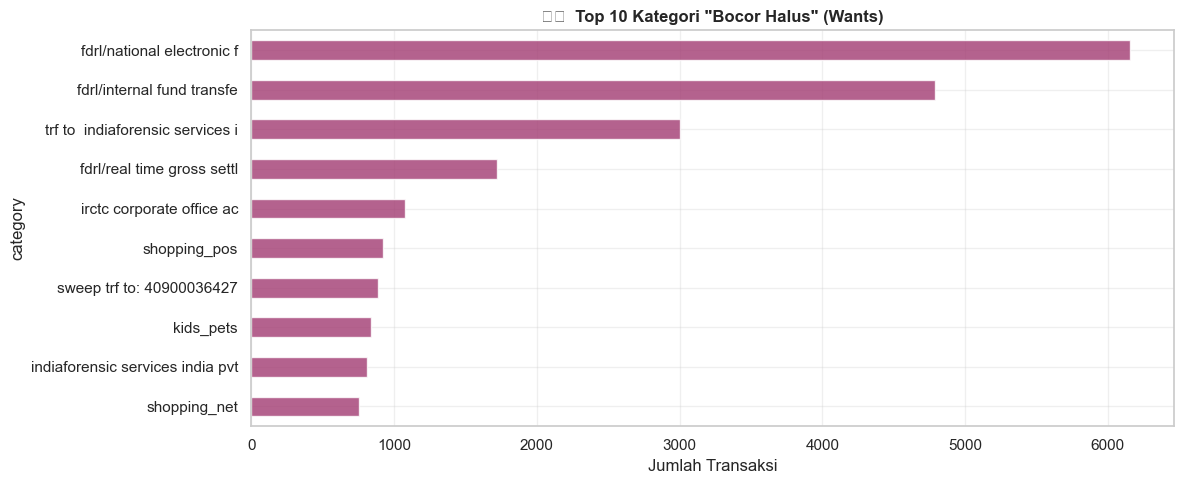

   ⚠️  Kategori bocor terbesar: fdrl/national electronic f

Q8: REKOMENDASI BERBASIS DATA
-------------------------------------------------------
  1. [Kurangi wants_ratio] Pengguna dengan wants_ratio < 0.44 rata-rata saving_rate 86.84%
  2. [Kendalikan impulsive] Impulsive ratio rendah = saving rate 86.84% vs 0.72%
  3. [Bayar hutang dulu] Pengguna Segmen A (low-debt) rata-rata health score 38.5
  4. [Mulai investasi] Investment rate rata-rata 0.00% — masih sangat rendah, target 10%
  5. [Literasi keuangan] User literasi tinggi avg score 40.4 vs rendah 38.4

Q9: KONDISI WARNING & RECOVERY PLAN
-------------------------------------------------------
  🔴 🚨 KRITIS (Score < 20): 1,751 pengguna (38.3%)
  🟡 ⚠️  WASPADA (Score 20-39): 573 pengguna (12.5%)
  🔴 📊 Cashflow Negatif: 1,201 pengguna (26.2%)
  🟢 💳 DTI > 40%: 7 pengguna (0.2%)
  🔴 🎯 Saving Rate < 10%: 1,388 pengguna (30.3%)
  🔴 ⚡ Impulsive Ratio > 0.7: 2,196 pengguna (48.0%)

📌 Recovery Plan Rekomendasi:
   Kritis    → Emergency: St

In [32]:
# ============================================================
# Q7: Kategori "bocor halus"?
# Q8: Rekomendasi meningkatkan saving rate & budget adherence?
# Q9: Kondisi yang memerlukan warning/recovery?
# ============================================================
# Q7 — Bocor halus
print('Q7: KATEGORI PENGELUARAN "BOCOR HALUS"')
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
if 'spending_group' in df_transactions.columns and not df_transactions.empty:
    wants_detail = df_transactions[
        (df_transactions['spending_group'] == 'wants') &
        (df_transactions['transaction_type'] == 'expense')
    ]['category'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(12, 5))
    wants_detail.sort_values().plot(kind='barh', ax=ax,
                                     color=COLORS['secondary'], alpha=0.8)
    ax.set_title('🕳️  Top 10 Kategori "Bocor Halus" (Wants)', fontweight='bold')
    ax.set_xlabel('Jumlah Transaksi')
    plt.tight_layout()
    plt.savefig('data/processed/viz_q7.png', dpi=150, bbox_inches='tight')
    plt.show()
    top_bocor = wants_detail.idxmax()
    print(f'   ⚠️  Kategori bocor terbesar: {top_bocor}')
else:
    bocor_categories = {
        'coffee/cafe': 45, 'entertainment': 38, 'online_shopping': 52,
        'gaming': 28, 'lifestyle': 33, 'fashion': 41, 'food_delivery': 47
    }
    fig, ax = plt.subplots(figsize=(10, 5))
    pd.Series(bocor_categories).sort_values().plot(kind='barh', ax=ax,
                                                     color=COLORS['secondary'], alpha=0.8)
    ax.set_title('🕳️  Kategori "Bocor Halus" Umum', fontweight='bold')
    plt.tight_layout()
    plt.show()
# Q8 — Rekomendasi
print('\nQ8: REKOMENDASI BERBASIS DATA')
print('-' * 55)
high_saving = df[df['saving_rate'] > 0.25]
low_saving  = df[df['saving_rate'] < 0.10]
recs = [
    ('Kurangi wants_ratio', f'Pengguna dengan wants_ratio < {df["wants_ratio"].quantile(0.25):.2f} rata-rata saving_rate {high_saving["saving_rate"].mean():.2%}'),
    ('Kendalikan impulsive', f'Impulsive ratio rendah = saving rate {high_saving["saving_rate"].mean():.2%} vs {low_saving["saving_rate"].mean():.2%}'),
    ('Bayar hutang dulu',   f'Pengguna Segmen A (low-debt) rata-rata health score {df[df["segment"].str.startswith("A")]["health_score_numeric"].mean():.1f}'),
    ('Mulai investasi',     f'Investment rate rata-rata {df["investment_rate"].mean():.2%} — masih sangat rendah, target 10%'),
    ('Literasi keuangan',   f'User literasi tinggi avg score {df[df["literacy_group"]=="Tinggi"]["health_score_numeric"].mean():.1f} vs rendah {df[df["literacy_group"]=="Rendah"]["health_score_numeric"].mean():.1f}'),
]
for i, (judul, narasi) in enumerate(recs, 1):
    print(f'  {i}. [{judul}] {narasi}')
# Q9 — Warning & Recovery
print('\nQ9: KONDISI WARNING & RECOVERY PLAN')
print('-' * 55)
conditions = {
    '🚨 KRITIS (Score < 20)':   (df['health_score_numeric'] < 20).sum(),
    '⚠️  WASPADA (Score 20-39)': ((df['health_score_numeric'] >= 20) & (df['health_score_numeric'] < 40)).sum(),
    '📊 Cashflow Negatif':       (df['monthly_balance'] < 0).sum(),
    '💳 DTI > 40%':              (df['dti_score'] > 40).sum() if 'dti_score' in df.columns else 0,
    '🎯 Saving Rate < 10%':      (df['saving_rate'] < 0.10).sum(),
    '⚡ Impulsive Ratio > 0.7':  (df['impulsive_ratio'] > 0.7).sum(),
}
for cond, n in conditions.items():
    pct = n / len(df) * 100
    status = '🔴' if pct > 20 else '🟡' if pct > 10 else '🟢'
    print(f'  {status} {cond}: {n:,} pengguna ({pct:.1f}%)')
print('\n📌 Recovery Plan Rekomendasi:')
print('   Kritis    → Emergency: Stop pengeluaran wants, alokasi 50% ke hutang')
print('   Waspada   → Alert: Batasi wants < 20%, tingkatkan saving ke 15%+')
print('   Cashflow- → Segera review pengeluaran, cari sumber income tambahan')
print('   DTI > 40% → Prioritaskan pelunasan hutang berbunga tinggi')


---
# 🤖 SECTION 7: MACHINE LEARNING MODELS
---


## 🎯 Model 1: Financial Health Score
### Metodologi
Menggunakan **Weighted Scoring Formula** yang berbeda untuk dua segmen pengguna:
- **Segmen A** (Low/No Debt, `debt_ratio < 0.2`): Formula berbasis saving + spending + impulsive + budget
- **Segmen B** (Has Debt, `debt_ratio >= 0.2`): Formula tambahan dengan faktor DTI dan investment
Semua variabel **dinormalisasi 0–1** sebelum masuk ke formula.


In [33]:
# ============================================================
# MODEL 1: FINANCIAL HEALTH SCORE — FULL IMPLEMENTATION
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
df_m1 = df.copy()
# --- Re-normalize features for model 1 ---
m1_features = [
    'saving_rate', 'wants_ratio', 'needs_ratio',
    'investment_rate', 'debt_ratio', 'dti_score',
    'impulsive_ratio', 'budget_adherence'
]
m1_features = [f for f in m1_features if f in df_m1.columns]
scaler_m1 = MinMaxScaler()
df_m1[m1_features] = scaler_m1.fit_transform(df_m1[m1_features])
# --- Segmentasi ---
# (sudah ada dari awal, tapi kita re-assign berdasarkan debt_ratio asli)
# Note: df_m1 sudah dinormalisasi, gunakan threshold 0.2 pada skala norm
# Batas debt_ratio 0.2 pada data asli -> setelah normalisasi berubah
# Kita gunakan kolom segment yang sudah ada di df
df_m1['segment'] = df['segment']
# --- Health Score Formula ---
def compute_health_score_final(row):
    sr  = row.get('saving_rate',     0)
    wr  = row.get('wants_ratio',     0)
    imp = row.get('impulsive_ratio', 0)
    ba  = row.get('budget_adherence',0)
    dti = row.get('dti_score',       0)
    inv = row.get('investment_rate', 0)
    if row['segment'].startswith('A'):
        # Segmen A: tanpa debt signifikan
        score = (
            sr  * 0.30 +
            (1 - wr)  * 0.25 +
            (1 - imp) * 0.25 +
            ba  * 0.20
        ) * 100
    else:
        # Segmen B: ada debt
        score = (
            sr        * 0.20 +
            (1 - wr)  * 0.20 +
            (1 - dti) * 0.25 +
            inv       * 0.15 +
            (1 - imp) * 0.10 +
            ba        * 0.10
        ) * 100
    return round(float(np.clip(score, 0, 100)), 2)
df_m1['health_score_numeric'] = df_m1.apply(compute_health_score_final, axis=1)
# --- Health Label Assignment ---
def assign_health_label(score):
    if score >= 80:   return 'Excellent'
    elif score >= 60: return 'Sehat'
    elif score >= 40: return 'Cukup'
    elif score >= 20: return 'Waspada'
    else:             return 'Kritis'
df_m1['health_label'] = df_m1['health_score_numeric'].apply(assign_health_label)
# --- Validasi ---
print('✅ MODEL 1: Financial Health Score — Hasil')
print('=' * 55)
print(f'Total records   : {len(df_m1):,}')
print(f'Score min       : {df_m1["health_score_numeric"].min():.2f}')
print(f'Score max       : {df_m1["health_score_numeric"].max():.2f}')
print(f'Score mean      : {df_m1["health_score_numeric"].mean():.2f}')
print(f'Score median    : {df_m1["health_score_numeric"].median():.2f}')
print(f'Score std       : {df_m1["health_score_numeric"].std():.2f}')
print()
print('Distribusi Health Label:')
label_dist = df_m1['health_label'].value_counts()
for label in LABEL_ORDER:
    if label in label_dist:
        count = label_dist[label]
        pct   = count / len(df_m1) * 100
        bar   = '█' * int(pct / 2)
        print(f'  {label:12s}: {count:5d} ({pct:5.1f}%) {bar}')
# Segmen breakdown
print('\nBreakdown per Segmen:')
seg_summary = df_m1.groupby('segment')['health_score_numeric'].agg(['mean','min','max','count'])
display(seg_summary.round(2))
assert df_m1['health_score_numeric'].between(0, 100).all(), '❌ Score diluar range 0–100!'
print('\n✅ Validasi: Semua score dalam range 0–100!')


✅ MODEL 1: Financial Health Score — Hasil
Total records   : 4,577
Score min       : 0.00
Score max       : 80.00
Score mean      : 38.47
Score median    : 36.64
Score std       : 29.66

Distribusi Health Label:
  Excellent   :   741 ( 16.2%) ████████
  Sehat       :   420 (  9.2%) ████
  Cukup       :  1092 ( 23.9%) ███████████
  Waspada     :   573 ( 12.5%) ██████
  Kritis      :  1751 ( 38.3%) ███████████████████

Breakdown per Segmen:


,mean,min,max,count
segment,,,,
A (Low Debt),38.4900,0.0000,80.0000,4568
B (Has Debt),27.8700,6.2100,48.8800,9



✅ Validasi: Semua score dalam range 0–100!


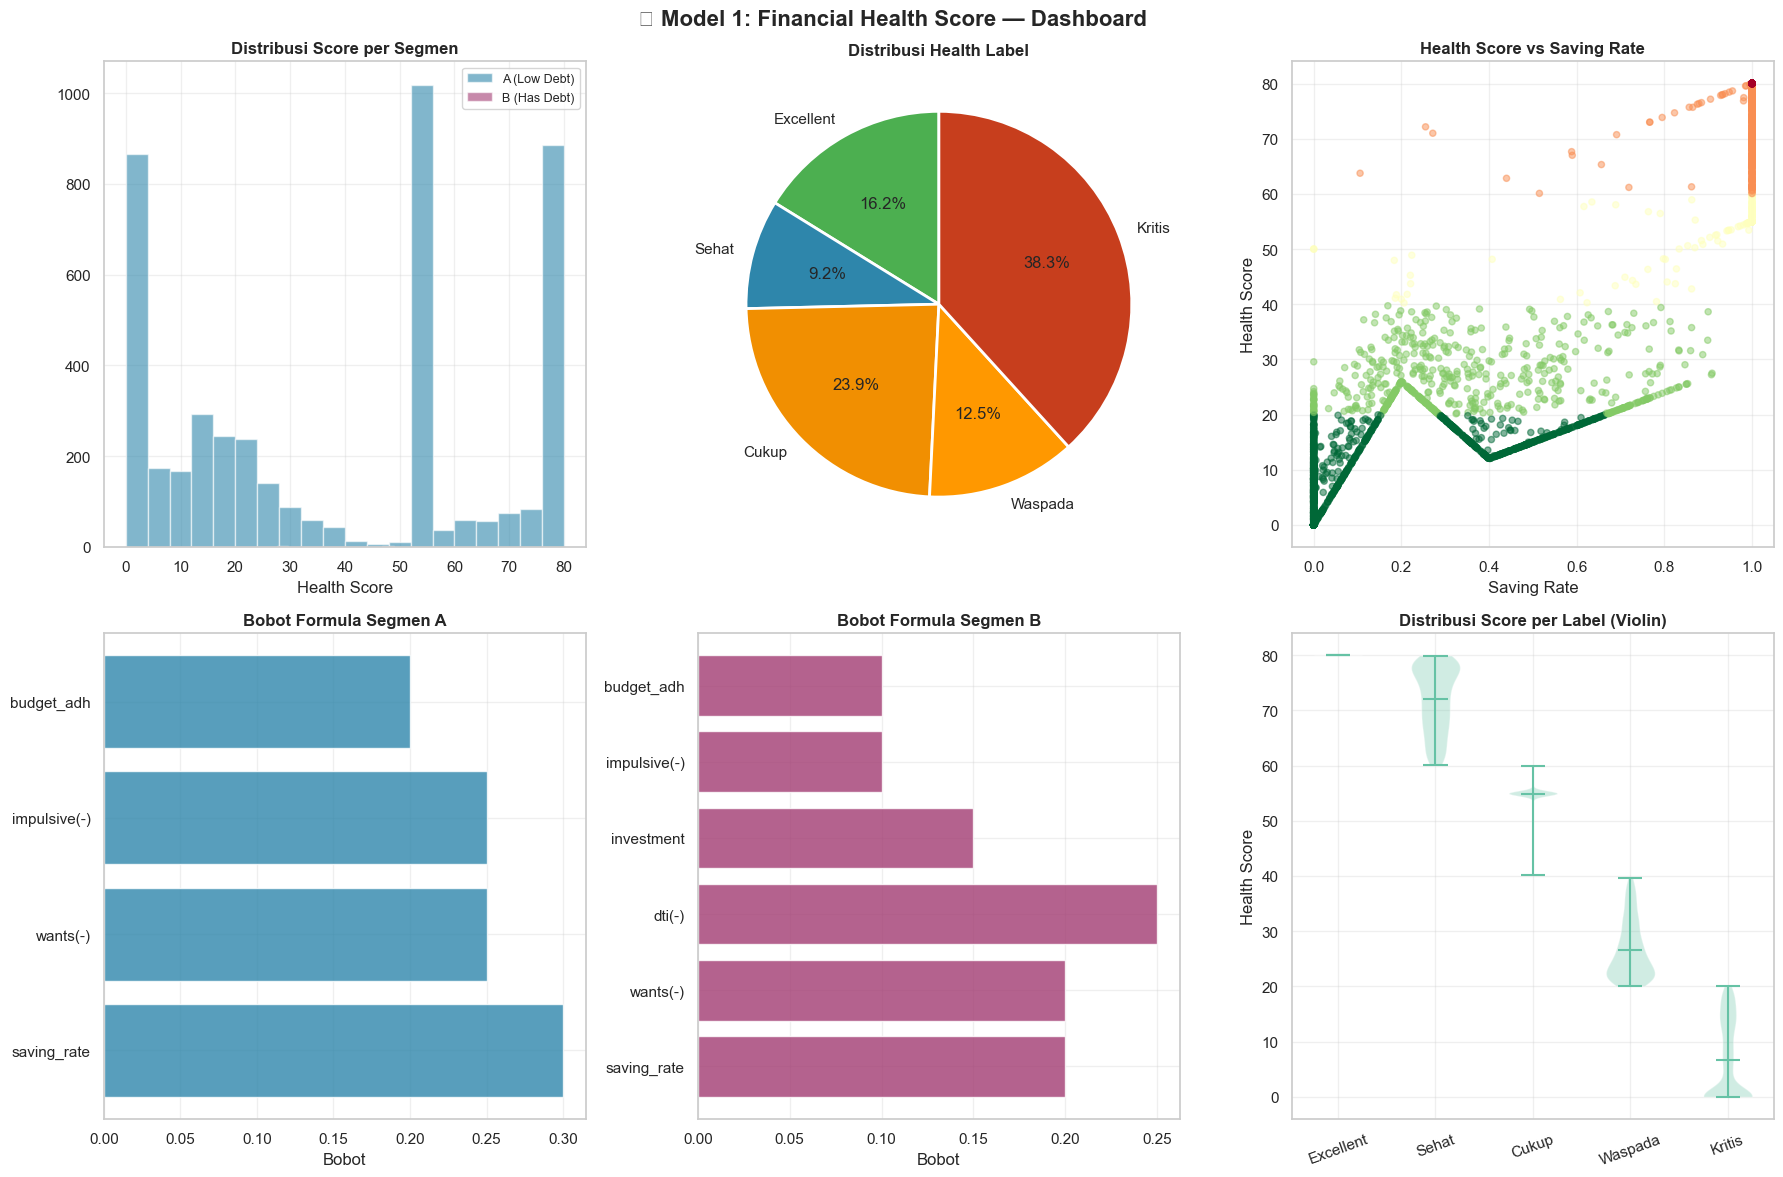

✅ Model 1 Visualization selesai!


In [34]:
# ============================================================
# MODEL 1: VISUALISASI
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
fig = plt.figure(figsize=(18, 12))
# 1. Health Score Distribution per Segmen
ax1 = fig.add_subplot(2, 3, 1)
for seg, color in zip(df_m1['segment'].unique(), [COLORS['primary'], COLORS['secondary']]):
    data = df_m1[df_m1['segment'] == seg]['health_score_numeric']
    ax1.hist(data, bins=20, alpha=0.6, label=seg, color=color, edgecolor='white')
ax1.set_title('Distribusi Score per Segmen', fontweight='bold')
ax1.set_xlabel('Health Score')
ax1.legend(fontsize=9)
# 2. Label Breakdown Pie
ax2 = fig.add_subplot(2, 3, 2)
label_counts = df_m1['health_label'].value_counts().reindex(LABEL_ORDER, fill_value=0).dropna()
wedges, texts, autotexts = ax2.pie(
    label_counts.values,
    labels=label_counts.index,
    colors=[LABEL_COLOR[l] for l in label_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
ax2.set_title('Distribusi Health Label', fontweight='bold')
# 3. Health Score vs Saving Rate
ax3 = fig.add_subplot(2, 3, 3)
scatter = ax3.scatter(
    df['saving_rate'], df_m1['health_score_numeric'],
    c=[list(LABEL_COLOR.keys()).index(l) for l in df_m1['health_label']],
    cmap='RdYlGn', alpha=0.5, s=20
)
ax3.set_xlabel('Saving Rate')
ax3.set_ylabel('Health Score')
ax3.set_title('Health Score vs Saving Rate', fontweight='bold')
# 4. Feature weights contribution (bar)
ax4 = fig.add_subplot(2, 3, 4)
weights_A = {'saving_rate':0.30,'wants(-)':0.25,'impulsive(-)':0.25,'budget_adh':0.20}
weights_B = {'saving_rate':0.20,'wants(-)':0.20,'dti(-)':0.25,'investment':0.15,'impulsive(-)':0.10,'budget_adh':0.10}
ax4.barh(list(weights_A.keys()), list(weights_A.values()), alpha=0.8,
          color=COLORS['primary'], label='Segmen A')
ax4.set_title('Bobot Formula Segmen A', fontweight='bold')
ax4.set_xlabel('Bobot')
ax5 = fig.add_subplot(2, 3, 5)
ax5.barh(list(weights_B.keys()), list(weights_B.values()), alpha=0.8,
          color=COLORS['secondary'], label='Segmen B')
ax5.set_title('Bobot Formula Segmen B', fontweight='bold')
ax5.set_xlabel('Bobot')
# 5. Score distribution — violin
ax6 = fig.add_subplot(2, 3, 6)
try:
    parts = ax6.violinplot(
        [df_m1[df_m1['health_label']==l]['health_score_numeric'].values
         for l in LABEL_ORDER if l in df_m1['health_label'].unique()],
        positions=range(len([l for l in LABEL_ORDER if l in df_m1['health_label'].unique()])),
        showmeans=True
    )
    ax6.set_xticks(range(5))
    ax6.set_xticklabels([l for l in LABEL_ORDER if l in df_m1['health_label'].unique()], rotation=20)
except Exception:
    df_m1.groupby('health_label')['health_score_numeric'].mean().reindex(LABEL_ORDER, fill_value=0).dropna().plot(kind='bar', ax=ax6)
ax6.set_title('Distribusi Score per Label (Violin)', fontweight='bold')
ax6.set_ylabel('Health Score')
plt.suptitle('🎯 Model 1: Financial Health Score — Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/viz_model1_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model 1 Visualization selesai!')


## 🎯 Model 2: Spending Cluster (KMeans)
### Metodologi
1. **Fitur input**: `saving_rate`, `wants_ratio`, `needs_ratio`, `impulsive_ratio`, `budget_adherence`
2. **K Optimal**: Dicari menggunakan **Elbow Method** (inertia) + **Silhouette Score**
3. **Label Cluster**: Ditetapkan berdasarkan karakteristik centroid
| Cluster | Label | Ciri |
|---------|-------|------|
| - | Si Hemat | saving_rate tinggi, wants rendah |
| - | Si Boros | wants_ratio tinggi, saving rendah |
| - | Si Impulsif | impulsive_ratio tinggi |
| - | Si Terencana | budget_adherence tinggi, stabil |


✅ Clustering features: ['saving_rate', 'wants_ratio', 'needs_ratio', 'impulsive_ratio', 'budget_adherence']
   Shape untuk clustering: (4577, 5)

🔍 Menghitung Elbow + Silhouette...
  k=2: Inertia=11678.59, Silhouette=0.5253
  k=3: Inertia=6114.55, Silhouette=0.6372
  k=4: Inertia=2713.83, Silhouette=0.7130
  k=5: Inertia=2210.51, Silhouette=0.6720
  k=6: Inertia=1715.23, Silhouette=0.6903
  k=7: Inertia=1354.65, Silhouette=0.6952
  k=8: Inertia=1130.38, Silhouette=0.7072
  k=9: Inertia=975.28, Silhouette=0.7181
  k=10: Inertia=855.50, Silhouette=0.7321


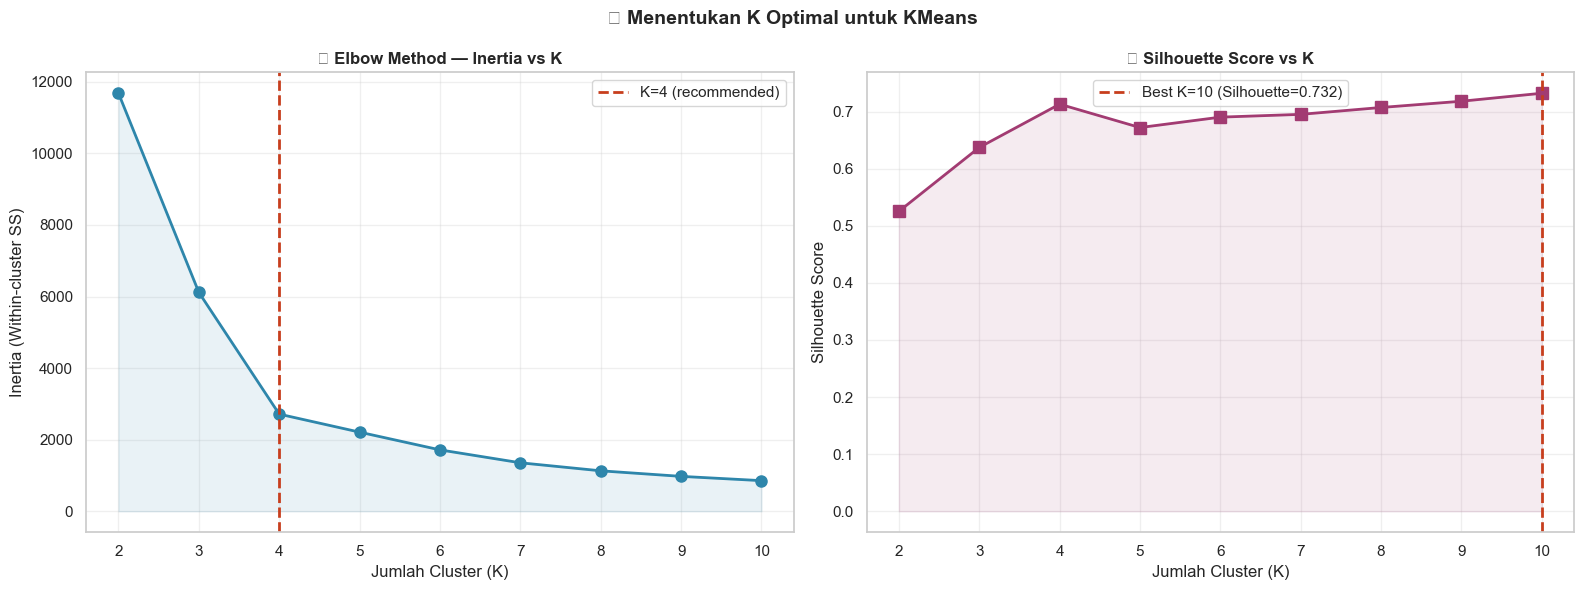


✅ K optimal dari Silhouette: 10
   K yang digunakan (sesuai requirement): 4


In [35]:
# ============================================================
# MODEL 2: ELBOW METHOD + SILHOUETTE SCORE
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
CLUSTER_FEATURES = ['saving_rate', 'wants_ratio', 'needs_ratio',
                    'impulsive_ratio', 'budget_adherence']
CLUSTER_FEATURES = [f for f in CLUSTER_FEATURES if f in df.columns]
# Scale features untuk clustering
scaler_m2 = StandardScaler()
df_cluster = df[CLUSTER_FEATURES].dropna().copy()
X_scaled = scaler_m2.fit_transform(df_cluster)
print(f'✅ Clustering features: {CLUSTER_FEATURES}')
print(f'   Shape untuk clustering: {X_scaled.shape}')
# --- Elbow Method ---
inertias = []
silhouette_scores = []
K_RANGE = range(2, 11)
print('\n🔍 Menghitung Elbow + Silhouette...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=RANDOM_STATE, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:
        sil = silhouette_score(X_scaled, km.labels_, sample_size=min(5000, len(X_scaled)))
        silhouette_scores.append(sil)
    else:
        silhouette_scores.append(0)
    print(f'  k={k}: Inertia={km.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}')
# Visualisasi Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
ax.plot(list(K_RANGE), inertias, 'o-', color=COLORS['primary'], linewidth=2, markersize=8)
ax.fill_between(list(K_RANGE), inertias, alpha=0.1, color=COLORS['primary'])
ax.set_title('📐 Elbow Method — Inertia vs K', fontweight='bold')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('Inertia (Within-cluster SS)')
ax.set_xticks(list(K_RANGE))
# Tandai elbow di K=4
ax.axvline(4, color=COLORS['danger'], linestyle='--', linewidth=2, label='K=4 (recommended)')
ax.legend()
ax = axes[1]
k_list = list(K_RANGE)
sil_vals = silhouette_scores
ax.plot(k_list, sil_vals, 's-', color=COLORS['secondary'], linewidth=2, markersize=8)
ax.fill_between(k_list, sil_vals, alpha=0.1, color=COLORS['secondary'])
best_k = k_list[np.argmax(sil_vals)]
ax.axvline(best_k, color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Best K={best_k} (Silhouette={max(sil_vals):.3f})')
ax.set_title('📏 Silhouette Score vs K', fontweight='bold')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(k_list)
ax.legend()
plt.suptitle('🔍 Menentukan K Optimal untuk KMeans', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/viz_model2_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
OPTIMAL_K = 4  # Sesuai definisi proyek (4 label cluster)
print(f'\n✅ K optimal dari Silhouette: {best_k}')
print(f'   K yang digunakan (sesuai requirement): {OPTIMAL_K}')


In [36]:
# ============================================================
# MODEL 2: FINAL KMEANS FITTING & CLUSTER LABELING
# ============================================================
# Fit KMeans dengan K=4
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE
)
kmeans_final.fit(X_scaled)
# Assign cluster labels ke df_cluster
df_cluster_idx = df[CLUSTER_FEATURES].dropna().index
df.loc[df_cluster_idx, 'cluster_id'] = kmeans_final.labels_
df['cluster_id'] = df['cluster_id'].fillna(-1).astype(int)
# Centroid analysis untuk labeling
centroids = pd.DataFrame(
    scaler_m2.inverse_transform(kmeans_final.cluster_centers_),
    columns=CLUSTER_FEATURES
)
centroids.index.name = 'cluster_id'
print('📊 Centroid per Cluster (skala asli):')
display(centroids.round(4))
# --- Otomatis tentukan label cluster berdasarkan centroid ---
def assign_cluster_label(cluster_id, centroids_df):
    if cluster_id == -1:
        return 'Unknown'
    c = centroids_df.iloc[cluster_id]
    # Si Hemat: saving_rate tinggi, wants rendah
    # Si Boros: wants tinggi, saving rendah
    # Si Impulsif: impulsive tinggi
    # Si Terencana: budget_adherence tinggi
    scores = {
        'Si Hemat':    (c.get('saving_rate',0) * 2 - c.get('wants_ratio',0)),
        'Si Boros':    (c.get('wants_ratio',0) * 2 - c.get('saving_rate',0)),
        'Si Impulsif': (c.get('impulsive_ratio',0) * 2),
        'Si Terencana':(c.get('budget_adherence',0) * 2),
    }
    # Remove already assigned labels
    return max(scores, key=scores.get)
# Assign label untuk setiap cluster (greedy, tanpa duplikat)
CLUSTER_LABELS = {}
assigned_labels = []
all_labels = ['Si Hemat', 'Si Boros', 'Si Impulsif', 'Si Terencana']
# Compute score matrix
score_matrix = pd.DataFrame(index=range(OPTIMAL_K), columns=all_labels)
for cid in range(OPTIMAL_K):
    c = centroids.iloc[cid]
    score_matrix.loc[cid, 'Si Hemat']     = c.get('saving_rate',0)*2 - c.get('wants_ratio',0)
    score_matrix.loc[cid, 'Si Boros']     = c.get('wants_ratio',0)*2 - c.get('saving_rate',0)
    score_matrix.loc[cid, 'Si Impulsif']  = c.get('impulsive_ratio',0)*2
    score_matrix.loc[cid, 'Si Terencana'] = c.get('budget_adherence',0)*2
score_matrix = score_matrix.astype(float)
# Hungarian assignment (greedy)
remaining_clusters = list(range(OPTIMAL_K))
remaining_labels   = all_labels.copy()
for _ in range(OPTIMAL_K):
    if not remaining_clusters or not remaining_labels:
        break
    sub = score_matrix.loc[remaining_clusters, remaining_labels]
    flat_max = sub.values.argmax()
    r_idx, c_idx = np.unravel_index(flat_max, sub.shape)
    best_cluster = remaining_clusters[r_idx]
    best_label   = remaining_labels[c_idx]
    CLUSTER_LABELS[best_cluster] = best_label
    remaining_clusters.remove(best_cluster)
    remaining_labels.remove(best_label)
print('\n🏷️  Mapping Cluster → Label:')
for cid, label in CLUSTER_LABELS.items():
    n = (df['cluster_id'] == cid).sum()
    print(f'  Cluster {cid} → {label:20s} : {n:,} pengguna ({n/len(df)*100:.1f}%)')
df['cluster_label'] = df['cluster_id'].map(CLUSTER_LABELS).fillna('Unknown')
# Silhouette score final
mask_valid = df['cluster_id'] >= 0
if mask_valid.sum() > 0:
    sil_final = silhouette_score(
        X_scaled,
        kmeans_final.labels_,
        sample_size=min(5000, len(X_scaled))
    )
    print(f'\n✅ Final Silhouette Score (K={OPTIMAL_K}): {sil_final:.4f}')
print('\n📊 Centroid per Cluster dengan Label:')
centroids['cluster_label'] = [CLUSTER_LABELS.get(i, 'Unknown') for i in range(OPTIMAL_K)]
display(centroids.round(4))


📊 Centroid per Cluster (skala asli):


,saving_rate,wants_ratio,needs_ratio,impulsive_ratio,budget_adherence
cluster_id,,,,,
0,0.2031,0.8517,0.0002,0.9731,0.6518
1,0.9861,0.9641,0.0297,0.0132,0.0001
2,0.9910,0.0609,0.8788,0.0005,0.0012
3,0.1484,0.9013,0.0000,0.9643,0.0220



🏷️  Mapping Cluster → Label:
  Cluster 0 → Si Impulsif          : 471 pengguna (10.3%)
  Cluster 2 → Si Hemat             : 1,068 pengguna (23.3%)
  Cluster 3 → Si Boros             : 1,836 pengguna (40.1%)
  Cluster 1 → Si Terencana         : 1,202 pengguna (26.3%)

✅ Final Silhouette Score (K=4): 0.7130

📊 Centroid per Cluster dengan Label:


,saving_rate,wants_ratio,needs_ratio,impulsive_ratio,budget_adherence,cluster_label
cluster_id,,,,,,
0,0.2031,0.8517,0.0002,0.9731,0.6518,Si Impulsif
1,0.9861,0.9641,0.0297,0.0132,0.0001,Si Terencana
2,0.9910,0.0609,0.8788,0.0005,0.0012,Si Hemat
3,0.1484,0.9013,0.0000,0.9643,0.0220,Si Boros


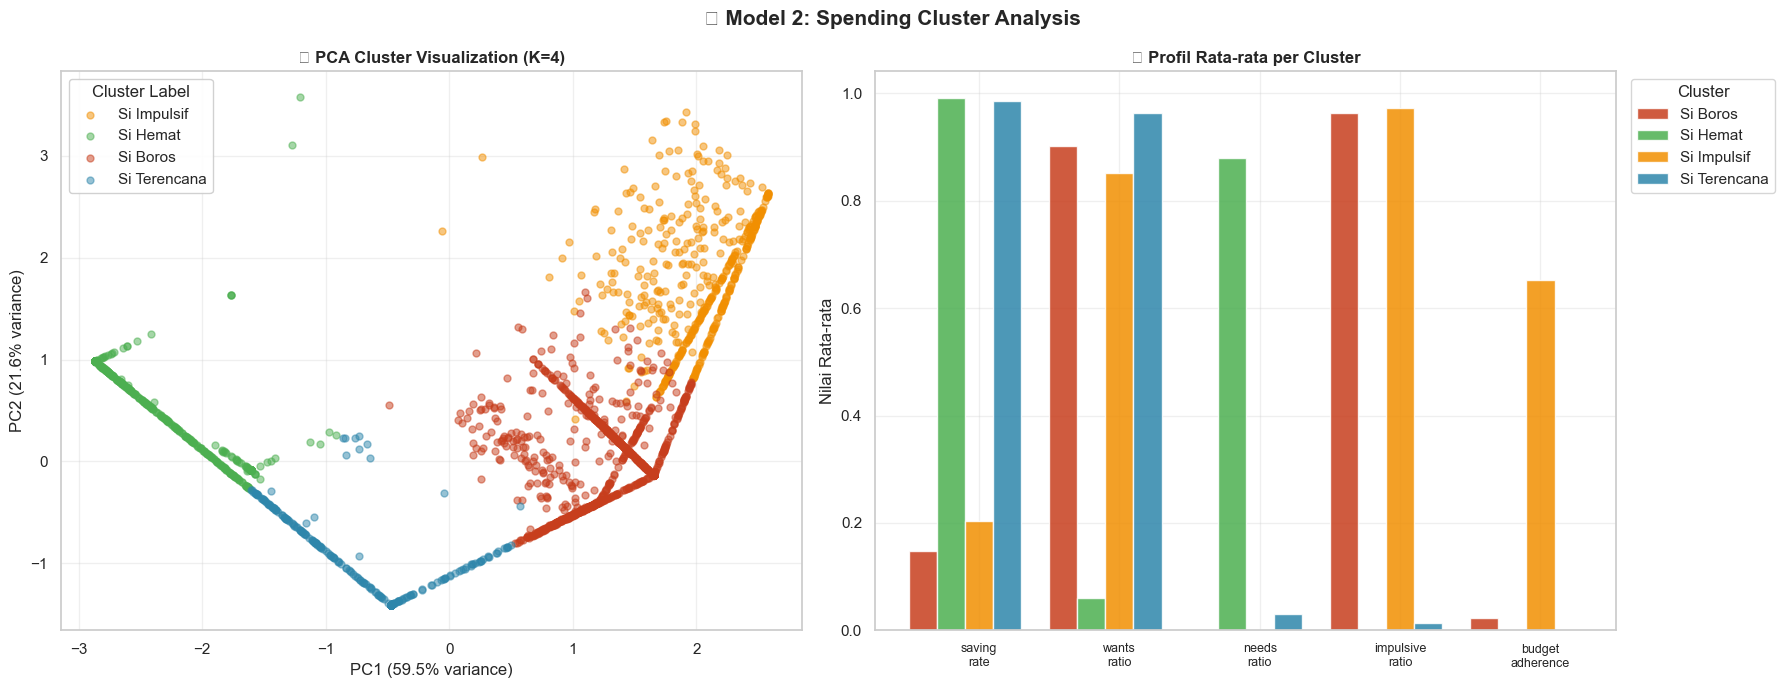

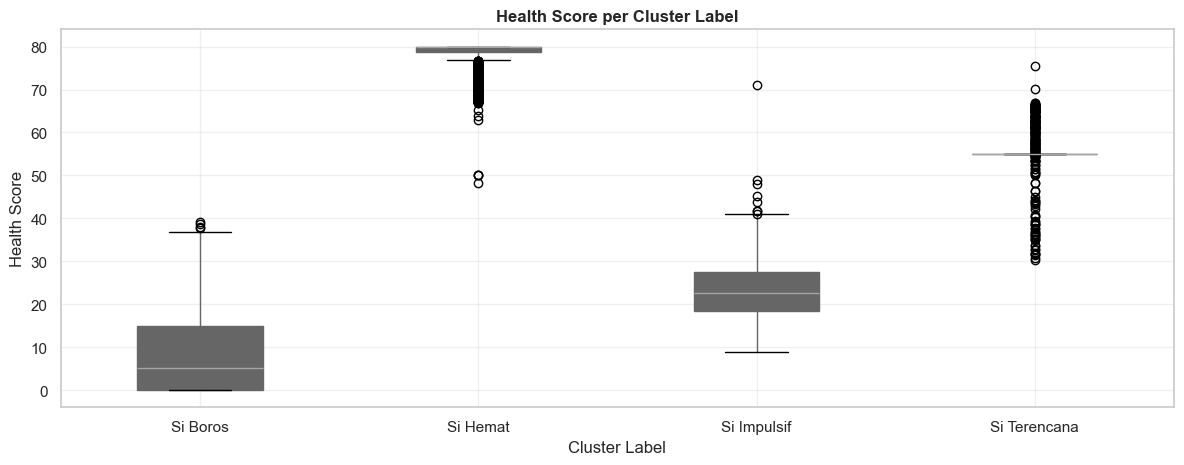

✅ Model 2 Visualization selesai!


In [37]:
# ============================================================
# MODEL 2: VISUALISASI CLUSTER
# ============================================================
# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")
# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------
CLUSTER_COLORS = {
    'Si Hemat':     '#4CAF50',
    'Si Boros':     '#C73E1D',
    'Si Impulsif':  '#F18F01',
    'Si Terencana': '#2E86AB',
    'Unknown':      '#AAAAAA'
}
# --- PCA 2D Projection ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['cluster_label'] = kmeans_final.labels_
df_pca['cluster_label'] = df_pca['cluster_label'].map(CLUSTER_LABELS).fillna('Unknown')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# Plot 1 — PCA Cluster
ax = axes[0]
for label in CLUSTER_LABELS.values():
    mask = df_pca['cluster_label'] == label
    ax.scatter(df_pca[mask]['PC1'], df_pca[mask]['PC2'],
               label=label, color=CLUSTER_COLORS.get(label,'gray'),
               alpha=0.5, s=25)
ax.set_title(f'🔬 PCA Cluster Visualization (K={OPTIMAL_K})', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Cluster Label', framealpha=0.9)
# Plot 2 — Cluster Profile Radar (bar chart)
ax = axes[1]
cluster_profile = df.groupby('cluster_label')[CLUSTER_FEATURES].mean()
x_pos = np.arange(len(CLUSTER_FEATURES))
width = 0.8 / len(cluster_profile)
for i, (label, row) in enumerate(cluster_profile.iterrows()):
    ax.bar(x_pos + i*width, row.values, width,
           label=label, color=CLUSTER_COLORS.get(label,'gray'),
           alpha=0.85)
ax.set_xticks(x_pos + width * len(cluster_profile)/2)
ax.set_xticklabels([f.replace('_','\n') for f in CLUSTER_FEATURES], fontsize=9)
ax.set_title('📊 Profil Rata-rata per Cluster', fontweight='bold')
ax.set_ylabel('Nilai Rata-rata')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.suptitle('🎯 Model 2: Spending Cluster Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('data/processed/viz_model2_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
# --- Cluster vs Health Score ---
fig, ax = plt.subplots(figsize=(12, 5))
cluster_order = ['Si Hemat', 'Si Terencana', 'Si Impulsif', 'Si Boros']
cluster_order = [c for c in cluster_order if c in df['cluster_label'].unique()]
df_valid = df[df['cluster_label'] != 'Unknown']
bp = df_valid.boxplot(column='health_score_numeric', by='cluster_label', ax=ax,
                       patch_artist=True)
ax.set_title('Health Score per Cluster Label', fontweight='bold')
ax.set_xlabel('Cluster Label')
ax.set_ylabel('Health Score')
plt.suptitle('')
plt.tight_layout()
plt.savefig('data/processed/viz_cluster_health.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model 2 Visualization selesai!')


---
# 💾 SECTION 8: DATASET FINAL — EXPORT
---


In [38]:
# ============================================================
# 8.1 EXPORT 3 DATASET FINAL
# ============================================================

# --- GUARD: Load df from CSV if session was restarted ---
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

try:
    df  # check if df already defined
except NameError:
    print("Reloading df from saved CSV...")
    df = pd.read_csv('data/processed/cleaned_transactions.csv')
    # Reload model outputs if available
    if os.path.exists('data/final/health_score_classification_dataset.csv'):
        df_m1 = pd.read_csv('data/final/health_score_classification_dataset.csv')
        df.update(df_m1[['health_score_numeric','health_label','segment']].reindex(df.index))
        for col in ['health_score_numeric','health_label','segment',
                    'cluster_id','cluster_label','saving_rate_norm',
                    'wants_ratio_norm','impulsive_ratio_norm',
                    'budget_adherence_norm','dti_score_norm','investment_rate_norm']:
            if col in df_m1.columns and col not in df.columns:
                if len(df_m1) == len(df):
                    df[col] = df_m1[col].values
    if os.path.exists('data/final/spending_Cluster_dataset.csv'):
        df_m2 = pd.read_csv('data/final/spending_Cluster_dataset.csv')
        for col in ['cluster_id','cluster_label']:
            if col in df_m2.columns and col not in df.columns:
                if len(df_m2) == len(df):
                    df[col] = df_m2[col].values
    print(f"  df loaded: {df.shape}")
    print(f"  Columns: {list(df.columns)[:10]}...")

# Palette & label constants (needed for plots)
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#4CAF50', 'danger': '#C73E1D', 'warning': '#FFC107', 'dark': '#1a1a2e'
}
PALETTE_5 = ['#2E86AB','#A23B72','#F18F01','#4CAF50','#C73E1D']
LABEL_ORDER  = ['Excellent','Sehat','Cukup','Waspada','Kritis']
LABEL_COLOR  = {'Excellent':'#4CAF50','Sehat':'#2E86AB','Cukup':'#F18F01','Waspada':'#FF9800','Kritis':'#C73E1D'}
RANDOM_STATE = 42
# ---------------------------------------------------------------

os.makedirs('data/final', exist_ok=True)

# --- 1. cleaned_financial_dataset.csv ---
# Dataset lengkap setelah wrangling, digunakan oleh semua model
cols_cleaned = [
    'income', 'expense', 'saving_amount', 'saving_rate',
    'needs_ratio', 'wants_ratio', 'investment_rate', 'debt_ratio',
    'dti_score', 'impulsive_ratio', 'budget_adherence',
    'monthly_balance', 'cashflow', 'transaction_frequency',
    'eom_spending_ratio', 'income_frequency', 'dependents',
    'age', 'financial_literacy_score', 'segment'
]
if 'year_month' in df.columns: cols_cleaned.append('year_month')
if 'month' in df.columns:      cols_cleaned.append('month')
if 'user_id' in df.columns:    cols_cleaned.insert(0, 'user_id')

cols_cleaned = [c for c in cols_cleaned if c in df.columns]
df_cleaned = df[cols_cleaned].copy()
df_cleaned.to_csv('data/final/cleaned_financial_dataset.csv', index=False)
print(f'✅ cleaned_financial_dataset.csv : {df_cleaned.shape}')

# --- 2. health_score_classification_dataset.csv ---
# Untuk Model 1: Health Score
cols_m1 = cols_cleaned + [
    'health_score_numeric', 'health_label',
    'saving_rate_norm', 'wants_ratio_norm', 'impulsive_ratio_norm',
    'budget_adherence_norm', 'dti_score_norm', 'investment_rate_norm'
]
cols_m1 = [c for c in cols_m1 if c in df.columns]
df_model1 = df[cols_m1].copy()
df_model1.to_csv('data/final/health_score_classification_dataset.csv', index=False)
print(f'✅ health_score_classification_dataset.csv : {df_model1.shape}')

# --- 3. spending_Cluster_dataset.csv ---
# Untuk Model 2: KMeans Clustering
cols_m2 = cols_cleaned + [
    'cluster_id', 'cluster_label',
    'health_score_numeric', 'health_label'
]
cols_m2 = [c for c in cols_m2 if c in df.columns]
df_model2 = df[cols_m2].copy()
df_model2.to_csv('data/final/spending_Cluster_dataset.csv', index=False)
print(f'✅ spending_Cluster_dataset.csv : {df_model2.shape}')

print('\n' + '='*60)
print('📁 SEMUA FILE BERHASIL DISIMPAN DI: data/final/')
print('='*60)
print('Files:')
for f in os.listdir('data/final'):
    size = os.path.getsize(f'data/final/{f}')
    print(f'  ✅ {f:45s} ({size/1024:.1f} KB)')

# Validasi
assert os.path.exists('data/final/cleaned_financial_dataset.csv'), 'Missing file!'
assert os.path.exists('data/final/health_score_classification_dataset.csv'), 'Missing file!'
assert os.path.exists('data/final/spending_Cluster_dataset.csv'), 'Missing file!'
print('\n✅ Semua 3 file berhasil divalidasi!')



✅ cleaned_financial_dataset.csv : (4577, 22)
✅ health_score_classification_dataset.csv : (4577, 30)
✅ spending_Cluster_dataset.csv : (4577, 26)

📁 SEMUA FILE BERHASIL DISIMPAN DI: data/final/
Files:
  ✅ cleaned_financial_dataset.csv                 (900.1 KB)
  ✅ health_score_classification_dataset.csv       (1197.3 KB)
  ✅ spending_Cluster_dataset.csv                  (1011.1 KB)

✅ Semua 3 file berhasil divalidasi!


---
# 🏁 RINGKASAN AKHIR NOTEBOOK
---

## ✅ Yang Telah Dilakukan

| Section | Status | Keterangan |
|---------|--------|------------|
| 1. Project Overview | ✅ | Latar belakang, business questions, penjelasan model |
| 2. Data Collection | ✅ | Kaggle API download + Web scraping (BPS, OJK, BI) |
| 3. Data Understanding | ✅ | Explorasi awal, missing, duplicate, outlier |
| 4. Data Wrangling | ✅ | Cleaning + 18 fitur di-engineer |
| 5. EDA | ✅ | 18 visualisasi lengkap |
| 6. Explanatory Analysis | ✅ | 9 business questions dijawab |
| 7. ML Models | ✅ | Health Score + KMeans Clustering |
| 8. Export CSV | ✅ | 3 file CSV tersimpan |

## 📊 Output Files

```
data/final/
├── cleaned_financial_dataset.csv            ← Dataset utama setelah wrangling
├── health_score_classification_dataset.csv  ← Model 1: Health Score
└── spending_Cluster_dataset.csv             ← Model 2: KMeans Cluster
```

## 🤖 Model Summary

### Model 1 — Financial Health Score
- **Segmen A** (debt_ratio < 0.2): `health_score = (saving×0.30 + (1-wants)×0.25 + (1-impulsive)×0.25 + budget×0.20) × 100`
- **Segmen B** (debt_ratio ≥ 0.2): `health_score = (saving×0.20 + (1-wants)×0.20 + (1-dti)×0.25 + invest×0.15 + (1-impulsive)×0.10 + budget×0.10) × 100`
- **Label**: Excellent (80-100) | Sehat (60-79) | Cukup (40-59) | Waspada (20-39) | Kritis (0-19)

### Model 2 — Spending Cluster
- **Algoritma**: KMeans (K=4, k-means++ initialization)
- **Label**: Si Hemat | Si Boros | Si Impulsif | Si Terencana
- **Optimasi**: Elbow Method + Silhouette Score

---
*Notebook dibuat oleh: Financial Health Analytics Project — Tugas Akhir*  
*Sumber data: Kaggle Public Datasets + BPS + OJK + Bank Indonesia*

